# Read dataset

### Imports

In [ ]:
#from HMM_EM import HMMPablo
import numpy.random as npr
import numpy as np
from scipy.stats import norm
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import random
from scipy.special import i0
from itertools import chain
import json
from scipy import signal
import matplotlib.font_manager as fm
from filtering_functions import hist_all, circular_distance
#from memoryIndex_functions import MemoryIndex , MemoryIndexbyTrl, output_MIs, maxnumberSurr
from preprocessing_functions import CleaningRawDataset_REC_TsA
import copy
from joblib import Parallel, delayed
# Import utility and visualization functions
from src.utils.data_processing import convert_to_angular_poked, rad_avg_poked
from src.visualization.plotting import plot_strategy_evolution, plot_histogram

### Aux functions

In [3]:
new_AngRad = {1: -3*np.pi/4, 2: -np.pi/2, 3: -np.pi/4, 4: 0, 5: np.pi/4, 6: np.pi/2, 7: 3*np.pi/4, 8: np.pi}

def convert_to_angular_poked(hist):
    AngRad_dict = {1: np.pi/4, 2: 0, 3: -np.pi/4, 4: -np.pi/2, 
                   5: -3*np.pi/4, 6: np.pi, 7: 3*np.pi/4, 8: np.pi/2}

    ang_ports_sess = []
    for sess in range(len(hist)):
        ang_ports = []
        for i, row in enumerate(hist[sess]):
            positions = np.where(row != 0)[0] 
            if positions.size > 0: 
                ang_ports.extend([AngRad_dict.get(pos + 1, np.nan) for pos in positions])
        ang_ports_sess.append(ang_ports)
    max_length = max(len(lst) for lst in ang_ports_sess)
    ang_ports_sess_padded = np.array([lst + [np.nan] * (max_length - len(lst)) for lst in ang_ports_sess])

    return ang_ports_sess_padded
def rad_avg_poked(hist):
    new_AngRad = {1: -3*np.pi/4, 2: -np.pi/2, 3: -np.pi/4, 4: 0, 5: np.pi/4, 6: np.pi/2, 7: 3*np.pi/4, 8: np.pi}
    avg_ang_sess=[]
    for sess in range(len(hist)):
        avg_ang=[]
        for i, row in enumerate(hist[sess]):
            # print(i)
            positions = np.where(row !=0)[0]  # columns where there is a 1
            if positions.size > 0:  # Only row with at least 1 val
                mapped_values = [new_AngRad.get(pos + 1, np.nan) for pos in positions]
                avg_ang.append(np.angle(np.exp(1j * np.array(mapped_values)).mean()))
        avg_ang_sess.extend(avg_ang)
    return avg_ang_sess
def hist_data_distance(Hist_data, port_seq, yes_port_seq, sess_distance):
  Hist_data_dist=np.full_like(Hist_data[sess_distance], np.nan)
  for ss in range(len(port_seq[sess_distance])):
    if (port_seq[sess_distance][ss]>yes_port_seq[sess_distance][ss] and (yes_port_seq[sess_distance][ss]>4 and (port_seq[sess_distance][ss]-yes_port_seq[sess_distance][ss])<=3)) or (port_seq[sess_distance][ss]<yes_port_seq[sess_distance][ss] and (yes_port_seq[sess_distance][ss]-port_seq[sess_distance][ss])>=5):
      Hist_data_dist[ss]=np.roll(np.flip(np.roll(Hist_data[sess_distance][ss],4-int(port_seq[sess_distance][ss]), axis=Hist_data.ndim-2), axis=Hist_data.ndim-2),-1,axis=Hist_data.ndim-2) #reversed
    else:
      Hist_data_dist[ss]=np.roll(Hist_data[sess_distance][ss],4-int(port_seq[sess_distance][ss]), axis=Hist_data.ndim-2)
  return Hist_data_dist
def circular_distance(angle1, angle2):
  angle_difference = np.abs(angle2 - angle1)
  wrapped_angle_difference = np.minimum(angle_difference, 2 * np.pi - angle_difference)
  return wrapped_angle_difference
def water_availability(datas):
    new_list = np.array([[array.item() for array in inner_list] for inner_list in datas])
    first_occurrences = [
        (sub_list.tolist().index(1) if 1 in sub_list.tolist() else len(sub_list) - 1) if len(sub_list) > 0 else None
        for sub_list in new_list
    ]
    first_occurrences_ = np.array([[] if value is None else [value] for value in first_occurrences])
    return first_occurrences_[0][0]


def subsample_data(arr_pokes, distance_seq, port_seq, lag_port_seq, NSamples, fraction=0.8):
    """Takes a 80%  of the data maintaining the coherence between variables"""
    if fraction==False:
       n_samples=NSamples
    else:
       n_samples = int(len(arr_pokes) * fraction)  # 80% de los datos
    indexes = np.random.choice(len(arr_pokes), n_samples, replace=False)  # Índices aleatorios sin repetición
    
    return arr_pokes[indexes], distance_seq[indexes], port_seq[indexes], lag_port_seq[indexes]
def MemoryIndex_histogram(Big_Hist_data, port_seq, lag_port_seq):
    h=np.sum([np.roll(Big_Hist_data[ss],8-int(port_seq[ss]), axis=0) for ss in range(len(Big_Hist_data))], axis=0)
    hLags=np.sum([np.roll(Big_Hist_data[ss],8-int(lag_port_seq[ss]), axis=0) for ss in range(len(Big_Hist_data))], axis=0)
    MI_distances=MemoryIndexbyTrl(h, 8)
    MILags_distances=MemoryIndexbyTrl(hLags, 8)
    return MI_distances, MILags_distances
def figure_data_based_MI(MI,MILags,MI_Surr2h_dist, MI_Surr24h_dist, colors):
    CI_MI2h_Surr=np.percentile(MI_Surr2h_dist, [99,1], axis=0)
    CI_MI_SurrLags=np.percentile(MI_Surr24h_dist, [99,1], axis=0)
    
    x_plot=np.array([0,1,2,3,4])
    fig, axs = plt.subplots(1,1, figsize=np.array([6.4, 6.4]) * .7)
    axs.scatter([x_plot[0]], [MI[0]],  color=colors[0], alpha=0.4,s=7, zorder=3)
    axs.plot(x_plot[:2], MI[:2], '--',  alpha=0.5, color=colors[0])
    axs.plot(x_plot[1:], MI[1:], '.-', alpha=0.5, color=colors[0], label='2h MI')
    axs.scatter([x_plot[0]], [MILags[0]],  color=colors[1], alpha=0.4,s=7, zorder=3)
    axs.plot(x_plot[:2], MILags[:2], '--',  alpha=0.5, color=colors[1])
    axs.plot(x_plot[1:], MILags[1:], '.-',  alpha=0.5, color=colors[1], label='24h MI')
    axs.fill_between(x_plot, CI_MI2h_Surr[0], CI_MI2h_Surr[1], color=colors[0], alpha=0.05)
    axs.plot(x_plot, np.nanmean(CI_MI2h_Surr, axis=0),'--' ,color=colors[0], alpha=0.1)
    axs.fill_between(x_plot, CI_MI_SurrLags[0], CI_MI_SurrLags[1], color=colors[1], alpha=0.05)
    axs.plot(x_plot, np.nanmean(CI_MI_SurrLags, axis=0),'--' ,color=colors[1], alpha=0.1)

    axs.axhline(y=0, color='grey', alpha=0.2)
    axs.spines[['top', 'right']].set_visible(False)
    axs.legend(loc= 'upper left',bbox_to_anchor=(1.2, 4.2), fontsize=8)
    axs.set_ylabel('Memory Index')
    axs.set_xlabel('Distance to Yesterday Port')
    axs.set_title('Model Free Memory Index \n Real Data')
    axs.set_ylim(-.2,0.4)
    axs.legend(loc= 'upper right',bbox_to_anchor=(1.3,1), fontsize=8)
    # plt.tight_layout()
def figure_model_based_MI(models, port_seq, lag_port_seq, distance_seq,MI_Surr2h_dist, MI_Surr24h_dist, colors, Transitions,SurrogateMode, DrugType, save=False):
    MI_m, MILags_m=model_based_MI(models, port_seq, lag_port_seq, distance_seq)[:2]
    Kappas = [np.exp(models[distance]['model'].observations.log_kappas) for distance in range(5)]
    kappas=Kappas[0][1]

    CI_MI2h_Surr=np.percentile(MI_Surr2h_dist, [99,1], axis=0)
    CI_MI_SurrLags=np.percentile(MI_Surr24h_dist, [99,1], axis=0)
    
    x_plot=np.array([0,1,2,3,4])
    fig, axs = plt.subplots(1,1, figsize=np.array([6.4, 6.4]) * .7)
    axs.scatter([x_plot[0]], [MI_m[0]],  color=colors[0], alpha=0.4,s=7, zorder=3)
    axs.plot(x_plot[:2], MI_m[:2], '--',  alpha=0.5, color=colors[0])
    axs.plot(x_plot[1:], MI_m[1:], '.-', alpha=0.5, color=colors[0], label='Model Pred. 2h MI')
    axs.scatter([x_plot[0]], [MI_m[0]],  color=colors[1], alpha=0.4,s=7, zorder=3)
    axs.plot(x_plot[:2], MILags_m[:2], '--',  alpha=0.5, color=colors[1])
    axs.plot(x_plot[1:], MILags_m[1:], '.-',  alpha=0.5, color=colors[1], label='Model Pred. 24h MI')
    axs.fill_between(x_plot, CI_MI2h_Surr[0], CI_MI2h_Surr[1], color=colors[0], alpha=0.05)
    axs.plot(x_plot, np.nanmean(CI_MI2h_Surr, axis=0),'--' ,color=colors[0], alpha=0.1)
    axs.fill_between(x_plot, CI_MI_SurrLags[0], CI_MI_SurrLags[1], color=colors[1], alpha=0.05)
    axs.plot(x_plot, np.nanmean(CI_MI_SurrLags, axis=0),'--' ,color=colors[1], alpha=0.1)

    axs.axhline(y=0, color='grey', alpha=0.2)
    axs.spines[['top', 'right']].set_visible(False)
    axs.legend(loc= 'upper left',bbox_to_anchor=(1.2, 4.2), fontsize=8)
    axs.set_ylabel('Memory Index')
    axs.set_xlabel('Distance to Yesterday Port')
    axs.set_title(f'Model Based Memory Index ({Transitions}) \n kappas={np.round(kappas[0])}')
    axs.set_ylim(-.2,0.4)
    axs.legend(loc= 'upper right',bbox_to_anchor=(1.3,1), fontsize=8)
    if save: 
        plt.savefig(f'D:\AutoSynaptopatiesData\Figures\HMM\Model_Based_MI_{DrugType}_{SurrogateMode}_{Transitions}.png', dpi=300, bbox_inches="tight")
    # plt.tight_layout()
def train_hmm_models(arr_pokes, distance_seq, port_seq, lag_port_seq, transitions, kappas,seed):
    """
    Trains HMM models for different distances and returns a dictionary with the models.

    Parameters:
    - arr_pokes: numpy array with the poke data.
    - distance_seq: numpy array with the corresponding distances.
    - port_seq_rad: numpy array with the port angles in radians.
    - lags_port_seq_rad: numpy array with the lagged port angles in radians.
    - transitions:str i.e.; (iidstationary, standard)

    Returns:
    - models: dictionary with the HMM models for each distance.
    """

    AngRad_dict = {1: np.pi/4, 2: 0, 3: -np.pi/4, 4: -np.pi/2, 5: -3*np.pi/4, 6: np.pi, 7: 3*np.pi/4, 8: np.pi/2}

    port_seq_rad=np.vectorize(AngRad_dict.get)(np.array(port_seq))
    lags_port_seq_rad=np.vectorize(AngRad_dict.get)(np.array(lag_port_seq))

    npr.seed(seed)  # Fijar la semilla para reproducibilidad
    K = 3  # States of the HMM (exploration, lag, today)
    D = 1  # Dimensions of the explorations (angles in radians)
    
    models = {}
    for i in range(5):  # Iterate over the 5 possible distances
        datas = arr_pokes[distance_seq == i]
        datas = [d[~np.isnan(d.astype(float))] for d in datas]
        datas = [d[:, None].astype('float64') if len(d) > 0 else np.array([[100.]]) for d in datas]

        masks = [~np.isnan(d) for d in datas]
        ports = port_seq_rad[distance_seq == i]
        ports_yes = lags_port_seq_rad[distance_seq == i]

        inputs = [np.array([0, ports_yes[sess], ports[sess]])[:, None] for sess in range(len(ports))]

        test_hmm = HMMPablo(K, D, observations='vonmisespablo', transitions=transitions)
        test_hmm.observations.log_kappas = copy.deepcopy(np.log(kappas[i]))
        # test_hmm.transitions.log_pis = copy.deepcopy(np.log(init_probabilities))
        test_hmm.fit(datas, inputs=inputs, masks=masks, num_iters=1000, tolerance=10**-5)

        models[i] = {
            'model': test_hmm,
            'datas': datas,
            'inputs': inputs,
            'masks': masks
        }

    return models
def model_based_MI(models, port_seq, lag_port_seq, distance_seq):
    Kappas = [np.exp(models[distance]['model'].observations.log_kappas) for distance in range(5)]
    Expectations=[[np.nanmean(models[distance]['model'].expected_states(models[distance]['datas'][ss], input=models[distance]['inputs'][ss], mask=models[distance]['masks'][ss])[0], axis=0) 
        for ss in range(len(models[distance]['datas']))] for distance in range(5)]
    # Estract the part I wanna modify (i=0)
    mod_data = np.array(Expectations[0])  
    # Compute the mean of the columns 1 and 2 at distance 0
    col_mean = np.mean(mod_data[:, 1:3], axis=1)

    # Replace columns 1 and 2 with the mean
    mod_data[:, 1] = col_mean
    mod_data[:, 2] = col_mean

    # Asigna los valores modificados de vuelta a Probabilities
    Expectations[0] = mod_data

    MI_distances=np.full(5, np.nan)
    MILags_distances=np.full(5, np.nan)
    Big_Hist_data=[]
    port_seq_sorted=[]
    lag_port_seq_sorted=[]
    distance_seq_sorted=[]

    for i in range(5):
        Big_Hist_data_model=np.full((np.shape(Expectations[i])[0],8), np.nan)
        ports=np.array(models[i]['inputs'])[:,-1]
        ports_yes=np.array(models[i]['inputs'])[:,1]
        kappas=Kappas[i]
        expectations=Expectations[i]
        for ss in range(len(expectations)):
            x = np.array([np.pi/4, 0, -np.pi/4, -np.pi/2, -3*np.pi/4, np.pi, 3*np.pi/4, np.pi/2])
            mu, kappa_val = ports[ss], kappas[-1]
            muE, kappaE = 0, kappas[0]
            muY, kappaY = ports_yes[ss], kappas[1]

            y = (expectations[ss][0] * np.exp(kappaE * np.cos(x - muE)) / (2 * np.pi * i0(kappaE)) +
                    expectations[ss][1] * np.exp(kappaY * np.cos(x - muY)) / (2 * np.pi * i0(kappaY)) +
                    expectations[ss][-1] * np.exp(kappa_val * np.cos(x - mu)) / (2 * np.pi * i0(kappa_val)))
            Big_Hist_data_model[ss]=y
        Big_Hist_data.extend(Big_Hist_data_model)

        new_port_seq=port_seq[distance_seq==i]
        port_seq_sorted.extend(new_port_seq)
        new_lag_port_seq=lag_port_seq[distance_seq==i]
        lag_port_seq_sorted.extend(new_lag_port_seq)
        new_distance_seq=distance_seq[distance_seq==i]
        distance_seq_sorted.extend(new_distance_seq)
        
        MI_distances[i], MILags_distances[i]=MemoryIndex_histogram(Big_Hist_data_model,new_port_seq,new_lag_port_seq  )

    return MI_distances, MILags_distances, np.array(Big_Hist_data), np.array(port_seq_sorted), np.array(lag_port_seq_sorted), np.array(distance_seq_sorted)
def distance_surrogates(Big_Hist_data,port_seq, lag_port_seq,distance_seq,mode,Nshuffles):
  AngRad_dict = {1: np.pi/4, 2: 0, 3: -np.pi/4, 4: -np.pi/2, 5: -3*np.pi/4, 6: np.pi, 7: 3*np.pi/4, 8: np.pi/2}

  port_seq_rad=np.vectorize(AngRad_dict.get)(np.array(port_seq))
  yes_port_seq_rad=np.vectorize(AngRad_dict.get)(np.array(lag_port_seq))

  if mode=='Distance':
    MI_Surr2h_dist=np.full((Nshuffles,5), np.nan)
    MI_Surr24h_dist=np.full((Nshuffles,5), np.nan)
    for i in range(Nshuffles):
        random.shuffle(distance_seq)
        MI_Surr2h=np.full(5, np.nan)
        MI_Surr24h=np.full(5, np.nan)
        for distance in range(5):
            histogram=[np.sum([np.roll(Big_Hist_data[distance_seq==distance][ss],8-int(port_seq[distance_seq==distance][ss]), axis=0) for ss in range(len(Big_Hist_data[distance_seq==distance]))], axis=0) ]
            histogram_Lags=[np.sum([np.roll(Big_Hist_data[distance_seq==distance][ss],8-int(lag_port_seq[distance_seq==distance][ss]), axis=0) for ss in range(len(Big_Hist_data[distance_seq==distance]))], axis=0) ]
            MI_Surr2h[distance]=MemoryIndexbyTrl(histogram, 8)
            MI_Surr24h[distance]=MemoryIndexbyTrl(histogram_Lags, 8)

        MI_Surr2h_dist[i]=MI_Surr2h
        MI_Surr24h_dist[i]=MI_Surr24h
    return MI_Surr2h_dist, MI_Surr24h_dist
  
  if mode=='Shuffle':
    MI_Surr2h_dist=np.full((Nshuffles,5), np.nan)
    MI_Surr24h_dist=np.full((Nshuffles,5), np.nan)
    for lags in range(2):
      if lags==0:
        for i in range(Nshuffles):
          shuffled_seq = port_seq.copy()
          random.shuffle(shuffled_seq)
          new_port_seq_rad=np.vectorize(AngRad_dict.get)(np.array(shuffled_seq))
          Distance_seq=circular_distance(new_port_seq_rad,yes_port_seq_rad)*8/(2*np.pi)
          MI_Surr2h=np.full(5, np.nan)
          for distance in range(5):
              histogram_Lags=[np.sum([np.roll(Big_Hist_data[Distance_seq==distance][ss],8-int(shuffled_seq[Distance_seq==distance][ss]), axis=0) for ss in range(len(Big_Hist_data[Distance_seq==distance]))], axis=0) ]
              MI_Surr2h[distance]=MemoryIndexbyTrl(histogram_Lags, 8)
          MI_Surr2h_dist[i]=MI_Surr2h
      if lags==1:
        for i in range(Nshuffles):
          shuffled_seq = lag_port_seq.copy()
          random.shuffle(shuffled_seq)
          new_yes_port_seq_rad=np.vectorize(AngRad_dict.get)(np.array(shuffled_seq))
          Distance_seq=circular_distance(port_seq_rad,new_yes_port_seq_rad)*8/(2*np.pi)
          MI_Surr24h=np.full(5, np.nan)
          for distance in range(5):
              histogram_Lags=[np.sum([np.roll(Big_Hist_data[Distance_seq==distance][ss],8-int(shuffled_seq[Distance_seq==distance][ss]), axis=0) for ss in range(len(Big_Hist_data[Distance_seq==distance]))], axis=0) ]
              MI_Surr24h[distance]=MemoryIndexbyTrl(histogram_Lags, 8)
          MI_Surr24h_dist[i]=MI_Surr24h

        MI_Surr2h_dist[i]=MI_Surr2h
    return MI_Surr2h_dist, MI_Surr24h_dist
  if mode=='Group':
    MI_Surr2h_dist=np.full((5,Nshuffles), np.nan)
    MI_Surr24h_dist=np.full((5,Nshuffles), np.nan)
    for distance in range(5):
      for lag in range(2):
          if lag==0:
              MI_Surr2h=np.full(Nshuffles, np.nan)
              new_port_seq=port_seq[distance_seq==distance]
              for i in range(Nshuffles):
                  random.shuffle(new_port_seq)
                  histogram=[np.sum([np.roll(Big_Hist_data[distance_seq==distance][ss],8-int(new_port_seq[ss]), axis=0) for ss in range(len(Big_Hist_data[distance_seq==distance]))], axis=0) ]
                  MI_Surr2h[i]=MemoryIndexbyTrl(histogram, 8)
              MI_Surr2h_dist[distance]=MI_Surr2h
          if lag==1:
              new_yes_port_seq=lag_port_seq[distance_seq==distance]
              MI_Surr24h=np.full(Nshuffles, np.nan)
              for i in range(Nshuffles):
                  random.shuffle(new_yes_port_seq)
                  histogram_Lags=[np.sum([np.roll(Big_Hist_data[distance_seq==distance][ss],8-int(new_yes_port_seq[ss]), axis=0) for ss in range(len(Big_Hist_data[distance_seq==distance]))], axis=0) ]
                  MI_Surr24h[i]=MemoryIndexbyTrl(histogram_Lags, 8) 
              MI_Surr24h_dist[distance]=MI_Surr24h
     
    return MI_Surr2h_dist.T, MI_Surr24h_dist.T
def dataset_MI(ALL_portsPoked_REC,ALL_PORTS_REC,ALL_PORTS_LAGS_REC, ALL_avgportsPoked_REC ):
    AngRad_dict = {1: np.pi/4, 2: 0, 3: -np.pi/4, 4: -np.pi/2, 5: -3*np.pi/4, 6: np.pi, 7: 3*np.pi/4, 8: np.pi/2}

    port_seqs=np.concatenate( [ALL_PORTS_REC[aa] for aa in range(len(ALL_PORTS_REC))])
    lags_port_seqs=np.concatenate( [ALL_PORTS_LAGS_REC[aa] for aa in range(len(ALL_PORTS_LAGS_REC))])
    arr_ports=port_seqs[lags_port_seqs>0]
    lags_arr_ports=lags_port_seqs[lags_port_seqs>0]
    hist_seqs=np.concatenate( [ALL_avgportsPoked_REC[aa] for aa in range(len(ALL_avgportsPoked_REC))])
    arr_pokes=hist_seqs[lags_port_seqs>0]
    all_trials_hist=hist_all(ALL_PORTS_REC,ALL_portsPoked_REC,56)
    arr_all_trials_pokes=np.concatenate([all_trials_hist[aa] for aa in range(len(all_trials_hist))])[lags_port_seqs>0]
    port_seq_rad=np.vectorize(AngRad_dict.get)(np.array(arr_ports))
    lags_port_seq_rad =np.vectorize(AngRad_dict.get)(np.array(lags_arr_ports))
    # np.random.shuffle(lags_port_seq_rad)
    distance_seq=circular_distance(port_seq_rad,lags_port_seq_rad)*8/(2*np.pi)
    Big_Hist_data=np.sum(arr_all_trials_pokes,axis=1)
    arr_all_trials_pokes_polar=convert_to_angular_poked(arr_all_trials_pokes)
    return Big_Hist_data, arr_pokes, arr_ports, lags_arr_ports, distance_seq, arr_all_trials_pokes,arr_all_trials_pokes_polar
def fig_only_probability_model_based(models, transitions, colors):
    x=range(0,5)
    fig, axs = plt.subplots(1,1, figsize=np.array([6.4, 6.4]) * .7)
    plt.rcParams['font.family'] = 'Arial'  # Usa Arial para toda la figura

    # kappas = [np.exp(models[distance]['model'].observations.log_kappas) for distance in range(5)]
    if isinstance(models, list):
        expectations=[[[np.nanmean(models[m][distance]['model'].expected_states(models[m][distance]['datas'][ss], input=models[m][distance]['inputs'][ss], mask=models[m][distance]['masks'][ss])[0], axis=0) 
        for ss in range(len(models[m][distance]['datas']))] for distance in range(5)] for m in range(len(models))]
        Probabilities_mean_arr= np.array([[np.nanmean(expectations[m][i], axis=0) for i in range(5)] for m in range(len(models))])
        CIs=np.array([np.percentile(Probabilities_mean_arr[:,i],[99,1],axis=0) for i in range(5)])

        CI_tod=CIs[:,:,-1]
        CI_yes=CIs[:,:,1]
        
        plt.plot(np.nanmean(Probabilities_mean_arr, axis=0)[:,1], '.-',  label= '24h Strategy', color=colors[1], alpha=0.4)
        plt.fill_between(x, CI_yes[:,0], CI_yes[:,1], color=colors[1], alpha=0.1)
        plt.plot(np.nanmean(Probabilities_mean_arr, axis=0)[:,2], '.-',  label= '2h Strategy', color=colors[0],alpha=0.4)
        plt.fill_between(x, CI_tod[:,0], CI_tod[:,1], color=colors[0], alpha=0.1)
    else:
        expectations=[[np.nanmean(models[distance]['model'].expected_states(models[distance]['datas'][ss], input=models[distance]['inputs'][ss], mask=models[distance]['masks'][ss])[0], axis=0) 
        for ss in range(len(models[distance]['datas']))] for distance in range(5)]
        Probabilities= [np.array(expectations[i]) for i in range(5)]
        # Estract the part I wanna modify (i=0)
        mod_data = Probabilities[0]  
        # Compute the mean of the columns 1 and 2 at distance 0
        col_mean = np.mean(mod_data[:, 1:3], axis=1)

        # Replace columns 1 and 2 with the mean
        mod_data[:, 1] = col_mean
        mod_data[:, 2] = col_mean

        # Asigna los valores modificados de vuelta a Probabilities
        Probabilities[0] = mod_data

        Probabilities_mean_arr= np.array([np.nanmean(Probabilities[i], axis=0) for i in range(5)])
    
        plt.scatter([x[0]], [Probabilities_mean_arr[0,1]],  color=colors[1], alpha=0.4,s=7, zorder=3)
        plt.plot(x[:2], Probabilities_mean_arr[:2,1], '--',  color=colors[1], alpha=0.4)
        plt.plot(x[1:], Probabilities_mean_arr[1:,1], '.-',  label= '24h Strategy', color=colors[1], alpha=0.4)
        plt.scatter([x[0]], [Probabilities_mean_arr[0,2]],  color=colors[0], alpha=0.4, s=7, zorder=3)
        plt.plot(x[:2], Probabilities_mean_arr[:2,2], '--',  label= '2h Strategy', color=colors[0],alpha=0.4)
        plt.plot(x[1:], Probabilities_mean_arr[1:,2], '.-',  label= '2h Strategy', color=colors[0],alpha=0.4)
    axs.spines[['top', 'right']].set_visible(False)
    axs.axhline(y=0, color='grey', alpha=0.2)
    axs.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
    axs.set_ylabel('Probability')
    axs.set_xlabel('Distance to yesterday Port')
    axs.set_title(f'Model Based Probability \n{transitions}')
    axs.set_ylim(-.2,0.4)
    axs.legend(loc= 'upper right',bbox_to_anchor=(1.3,1), fontsize=8)
    # plt.tight_layout()
def figure_expectations_model_based(models, transitions):
    kappas = [np.exp(models[distance]['model'].observations.log_kappas) for distance in range(5)]
    expectations=[[np.nanmean(models[distance]['model'].expected_states(models[distance]['datas'][ss], input=models[distance]['inputs'][ss], mask=models[distance]['masks'][ss])[0], axis=0) 
    for ss in range(len(models[distance]['datas']))] for distance in range(5)]
    Probabilities_mean_arr= np.array([np.nanmean(expectations[i], axis=0) for i in range(5)])
    CIs=np.array([np.percentile(expectations[i],[99,1],axis=0) for i in range(5)])

    CI_tod=CIs[:,:,-1]
    CI_yes=CIs[:,:,1]
    CI_expl=CIs[:,:,0]

    fig, axs = plt.subplots(2,3, figsize=np.array([6.4*3, 4.8*2]) * .7)
    axs[0,0].spines[['top', 'right']].set_visible(False)
    axs[0,0].plot(expectations[0], linewidth=0.5, label=['Exploration', 'Yesterday', 'Today'])
    axs[0,0].set_ylim(0,1)
    axs[0,0].set_ylabel('Probability')
    axs[0,0].set_xlabel('Trial Number')
    axs[0,0].set_title('Distance0')


    axs[0,1].spines[['top', 'right']].set_visible(False)
    axs[0,1].plot(expectations[1], linewidth=0.5, label=['Exploration', 'Yesterday', 'Today'])
    axs[0,1].set_ylim(0,1)
    axs[0,1].set_ylabel('Probability')
    axs[0,1].set_xlabel('Trial Number')
    axs[0,1].set_title('Distance1')

    axs[0,2].spines[['top', 'right']].set_visible(False)
    axs[0,2].plot(expectations[2], linewidth=0.5, label=['Exploration', 'Yesterday', 'Today'])
    axs[0,2].legend(loc='upper right', bbox_to_anchor=(1.4, 1.05))
    axs[0,2].set_ylim(0,1)
    axs[0,2].set_ylabel('Probability')
    axs[0,2].set_xlabel('Trial Number')
    axs[0,2].set_title('Distance2')

    axs[1,0].spines[['top', 'right']].set_visible(False)
    axs[1,0].plot(expectations[3], linewidth=0.5, label=['Exploration', 'Yesterday', 'Today'])
    axs[1,0].set_ylim(0,1)
    # axs[1,1].legend(loc='upper right', bbox_to_anchor=(1.4, 1.05))
    axs[1,0].set_ylabel('Probability')
    axs[1,0].set_xlabel('Trial Number')
    axs[1,0].set_title('Distance3')

    axs[1,1].spines[['top', 'right']].set_visible(False)
    axs[1,1].plot(expectations[4], linewidth=0.5, label=['Exploration', 'Yesterday', 'Today'])
    axs[1,1].set_ylim(0,1)
    # axs[1,1].legend(loc='upper right', bbox_to_anchor=(1.4, 1.05))
    axs[1,1].set_ylabel('Probability')
    axs[1,1].set_xlabel('Trial Number')
    axs[1,1].set_title('Distance4')

    x=range(0,5)
    axs[1,2].plot(Probabilities_mean_arr[:,0], '.-',  label= 'Explotarion',alpha=0.1)
    axs[1,2].fill_between(x, CI_expl[:,0], CI_expl[:,1], color='tab:blue', alpha=0.05)
    axs[1,2].plot(Probabilities_mean_arr[:,1], '.-',  label= 'Yesterday',alpha=0.4)
    axs[1,2].fill_between(x, CI_yes[:,0], CI_yes[:,1], color='tab:orange', alpha=0.1)
    axs[1,2].plot(Probabilities_mean_arr[:,2], '.-',  label= 'Today',alpha=0.4)
    axs[1,2].fill_between(x, CI_tod[:,0], CI_tod[:,1], color='tab:green', alpha=0.1)
    axs[1,2].spines[['top', 'right']].set_visible(False)
    axs[1,2].set_ylim(0,1)
    axs[1,2].legend(loc='upper right', bbox_to_anchor=(1.35, 1))
    axs[1,2].set_ylabel('Probability')
    axs[1,2].set_xlabel('Distance to yesterday Port')
    axs[1,2].set_title('Probability over Distance')

    fig.suptitle(f'OUPUT FIT {transitions} : RECALL \nKappas= {np.round(kappas[0][1][0])}')

    plt.tight_layout()


def fig_probability_model_free(Hist_data, port_seq, lag_port_seq,Surr_Prob_2h, Surr_Prob_24h,colors, DrugType,SurrogateMode, save=False):  
    Probability=probability_model_free(Hist_data, port_seq, lag_port_seq)
    CIProb_2hSurr=np.percentile(Surr_Prob_2h, [99,1], axis=0)
    CIProb_24hSurr=np.percentile(Surr_Prob_24h, [99,1], axis=0)

    x=range(0,5)
    fig, axs = plt.subplots(1,1, figsize=np.array([6.4, 6.4]) * .7)
    plt.rcParams['font.family'] = 'Arial'  # Usa Arial para toda la figura
    plt.scatter([x[0]], [Probability[0,1]],  color=colors[1], alpha=0.4,s=7, zorder=3)
    plt.plot(x[:2], Probability[:2,1], '--',  color=colors[1], alpha=0.4)
    plt.fill_between(x[:2], CIProb_24hSurr[0][:2], CIProb_24hSurr[1][:2], color=colors[1], alpha=0.05)
    plt.plot(x[1:], Probability[1:,1], '.-',  label= '24h Strategy', color=colors[1], alpha=0.4)
    plt.fill_between(x[1:], CIProb_24hSurr[0][1:], CIProb_24hSurr[1][1:], color=colors[1], alpha=0.05)

    plt.scatter([x[0]], [Probability[0,2]],  color=colors[0], alpha=0.4, s=7, zorder=3)
    plt.plot(x[:2], Probability[:2,2], '--',   color=colors[0],alpha=0.4)
    plt.fill_between(x[:2], CIProb_2hSurr[0][:2], CIProb_2hSurr[1][:2], color=colors[0], alpha=0.05)
    plt.plot(x[1:], Probability[1:,2], '.-',  label= '2h Strategy', color=colors[0],alpha=0.4)
    plt.fill_between(x[1:], CIProb_2hSurr[0][1:], CIProb_2hSurr[1][1:], color=colors[0], alpha=0.05)

    axs.spines[['top', 'right']].set_visible(False)
    axs.axhline(y=0, color='grey', alpha=0.2)
    axs.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
    axs.set_ylabel('Probability')
    axs.set_xlabel('Distance to yesterday Port')
    axs.set_title(f'Model Free Probability')
    axs.set_ylim(-0.01,0.3)
    axs.legend(loc= 'upper right',bbox_to_anchor=(1.3,1), fontsize=8)
    if save:
        plt.savefig(f'D:\AutoSynaptopatiesData\Figures\Model_free\Probabilities_model_free{DrugType}_{SurrogateMode}.png', dpi=300, bbox_inches="tight")
def probability_model_free(Hist_data, port_seq, lag_port_seq, distance_flag=True, distance_seq=None):
    AngRad_dict = {1: np.pi/4, 2: 0, 3: -np.pi/4, 4: -np.pi/2, 5: -3*np.pi/4, 6: np.pi, 7: 3*np.pi/4, 8: np.pi/2}
    if distance_flag==True:
        port_seq_rad=np.vectorize(AngRad_dict.get)(np.array(port_seq))
        yes_port_seq_rad=np.vectorize(AngRad_dict.get)(np.array(lag_port_seq))
        distance_seq=circular_distance(port_seq_rad,yes_port_seq_rad)*8/(2*np.pi)
    elif distance_seq is None:
        raise ValueError("If 'distance_flag' is False, 'distance_seq' must be fed.")

    sess0=np.array(distance_seq)==0.0
    sess1=np.array(distance_seq)==1.0
    sess2=np.array(distance_seq)==2.0
    sess3=np.array(distance_seq)==3.0
    sess4=np.array(distance_seq)==4.0
    # Generate histograms for all distances
    hist0 = hist_data_distance(Hist_data, port_seq, lag_port_seq, sess0)
    hist1 = hist_data_distance(Hist_data, port_seq, lag_port_seq, sess1)
    hist2 = hist_data_distance(Hist_data, port_seq, lag_port_seq, sess2)
    hist3 = hist_data_distance(Hist_data, port_seq, lag_port_seq, sess3)
    hist4 = hist_data_distance(Hist_data, port_seq, lag_port_seq, sess4)

    # Combine the histograms in a list
    histograms = [hist0,hist1,hist2,hist3,hist4]

    bin_centers = np.linspace(-np.pi, np.pi, num=16, endpoint=False) + np.pi / 8
    bin_width = bin_centers[1] - bin_centers[0]
    bins = np.concatenate([bin_centers - bin_width / 2, [bin_centers[-1] + bin_width / 2]])
    Probability=np.full((5,3), np.nan)
    for i in range(5): 
        counts, bin_edges=np.histogram(rad_avg_poked(histograms[i]),bins=bins, density=False)
        if i==0:
            MeanExplor = (np.sum(counts)-counts[7])/15
            P2 = ((counts[7]-MeanExplor)/np.sum(counts))/2
            P1 = ((counts[7]-MeanExplor)/np.sum(counts))/2
            P0 = 1-(P2+P1)
        else:
            MeanExplor = (np.sum(counts)-(counts[7])+counts[7+i*2])/14
            P1 = (counts[7+i*2]-MeanExplor)/np.sum(counts)
            P2 = (counts[7]-MeanExplor)/np.sum(counts)
            P0 = 1-(P2+P1)
        P0, P1, P2 = max(P0, 0), max(P1, 0), max(P2, 0)
        Probability[i]=np.array([P0, P1, P2])
    return(Probability)
def compute_surrogate_mode_free_probability(Hist_data, port_seq, lag_port_seq, mode ):
    """ Computes the Probabilities & Lag Probabilities with shuffled ports """
    if mode=='distance':
        AngRad_dict = {1: np.pi/4, 2: 0, 3: -np.pi/4, 4: -np.pi/2, 5: -3*np.pi/4, 6: np.pi, 7: 3*np.pi/4, 8: np.pi/2}
        port_seq_rad=np.vectorize(AngRad_dict.get)(np.array(port_seq))
        yes_port_seq_rad=np.vectorize(AngRad_dict.get)(np.array(lag_port_seq))
        distance_seq=circular_distance(port_seq_rad,yes_port_seq_rad)*8/(2*np.pi)
        shuffled_distances = distance_seq.copy()  # Copia para evitar modificar el original
        np.random.shuffle(shuffled_distances)
        ProbT = probability_model_free(Hist_data, port_seq, lag_port_seq,distance_flag=False,distance_seq=shuffled_distances )[:,2]
        ProbY = probability_model_free(Hist_data, port_seq, lag_port_seq,distance_flag=False,distance_seq=shuffled_distances)[:,1]
    if mode=='Shuffle':
        shuffled_ports = port_seq.copy()  # Copia para evitar modificar el original
        np.random.shuffle(shuffled_ports)
        ProbT = probability_model_free(Hist_data, shuffled_ports, lag_port_seq, distance_flag=True)[:,2]
        lag_shuffled_ports = lag_port_seq.copy()
        np.random.shuffle(lag_shuffled_ports)
        ProbY = probability_model_free(Hist_data, port_seq, lag_shuffled_ports,distance_flag=True)[:,1]
    return ProbT, ProbY

<>:125: SyntaxWarning: invalid escape sequence '\A'
<>:471: SyntaxWarning: invalid escape sequence '\A'
<>:125: SyntaxWarning: invalid escape sequence '\A'
<>:471: SyntaxWarning: invalid escape sequence '\A'
C:\Users\User\AppData\Local\Temp\ipykernel_29536\992088869.py:125: SyntaxWarning: invalid escape sequence '\A'
  plt.savefig(f'D:\AutoSynaptopatiesData\Figures\HMM\Model_Based_MI_{DrugType}_{SurrogateMode}_{Transitions}.png', dpi=300, bbox_inches="tight")
C:\Users\User\AppData\Local\Temp\ipykernel_29536\992088869.py:471: SyntaxWarning: invalid escape sequence '\A'
  plt.savefig(f'D:\AutoSynaptopatiesData\Figures\Model_free\Probabilities_model_free{DrugType}_{SurrogateMode}.png', dpi=300, bbox_inches="tight")


### Read code

In [4]:
ALL_portsPoked_REC,ALL_avgportsPoked_REC,ALL_PORTS_REC, ALL_PORTS_LAGS_REC, ALL_FirstTrlWaterAvai_REC =CleaningRawDataset_REC_TsA('CONTROL', 'CONTROL')

Big_Hist_data, arr_pokes, arr_ports, lags_arr_ports, distance_seq, arr_all_trials_pokes, arr_all_trials_pokes_polar=dataset_MI(ALL_portsPoked_REC,ALL_PORTS_REC,ALL_PORTS_LAGS_REC, ALL_avgportsPoked_REC)


c:\Users\User\Documents\cajal\code\preprocessing_functions.py:1235: RuntimeWarning: Mean of empty slice.
  avgportsPoked[trial]=np.angle(np.exp(1j * rad_pokes).mean())
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\User\Documents\cajal\code\preprocessing_functions.py:1243: RuntimeWarning: Mean of empty slice.
  avgportsPoked[trial]=np.angle(np.exp(1j * rad_pokes).mean())


In [5]:
np.shape(Big_Hist_data)

(2683, 8)

In [6]:
np.mean(np.sum(Big_Hist_data, axis=1))

np.float64(3.636228102869922)

In [7]:
np.shape(ALL_portsPoked_REC)

(47, 157, 56)

In [8]:
poke_sequences = []
pokes_per_session = []

for animal in ALL_portsPoked_REC:
    for session in animal:
        pokes = 0
        for trial in session:
            if ~np.isnan(trial).all():
                print(len(trial))
                pokes += len(trial)
                poke_sequences.append(trial)
        if pokes > 0:
            pokes_per_session.append(pokes)

2
1
1
2
2
2
2
1
1
1
1
1
1
1
2
2
1
1
1
1
2
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
3
2
1
1
1
1
1
1
2
2
2
1
1
1
1
1
1
1
1
1
1
1
2
1
1
2
1
2
1
1
1
1
2
2
3
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
1
2
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
2
1
1
1
1
1
1
1
1
1
2
1
1
1
1
1
1
1
2
1
1
2
1
1
1
1
1
1
1
2
1
1
1
2
1
1
1
1
2
2
2
2
2
1
2
2
2
1
2
1
2
2
2
2
2
1
1
1
1
1
1
2
2
2
3
1
1
2
2
1
2
2
2
1
2
2
3
2
1
2
2
2
1
1
1
1
1
1
1
2
1
1
1
2
1
1
1
1
1
1
2
2
1
2
2
1
1
1
1
2
1
1
1
2
1
2
1
1
2
1
2
1
1
2
1
2
2
1
2
2
1
3
2
2
2
1
1
1
1
1
1
1
1
1
2
1
1
2
1
1
1
1
1
2
2
1
1
2
1
1
1
2
1
1
1
2
2
1
2
1
1
2
1
2
1
1
1
2
1
2
1
2
1
1
2
2
2
1
2
2
1
1
1
1
2
2
2
1
2
2
1
1
1
2
2
3
1
1
2
1
1
2
2
1
1
1
1
1
1
1
2
1
1
2
2
1
1
1
2
1
1
2
1
2
2
1
1
1
1
1
1
1
1
1
1
2
1
1
1
2
2
1
2
1
1
1
1
2
1
2
2
2
2
2
1
1
2
2
1
1
2
2
1
2
2
2
2
1
1
1
2
1
1
1
2
1
3
3
2
1
2
1
3
1
2
1
2
2
2
1
1
2
2
3
2
2
1
1
2
1
1
2
2
1
2
1
1
1
1
2
2
2
2
2
1
2
1
1
2
1
1
1
1
1
2
1
1
2
1
2
1
2
1
1
2
1
1
2
1
1
2
1
1
1
1
2
1
2
1
2
1
1
2
2
2
2
1
2
2
1
2
2
2
2
2
2
1
2
2
1
1
1
1
2
1
1
1
1
2
2
3


In [9]:
poke_sequences = []
pokes_per_session = []

for animal in ALL_portsPoked_REC:
    for session in animal:
        pokes = 0
        for trial in session:
            if ~np.isnan(trial).all():
                print(len(trial))
                pokes += len(trial)
                poke_sequences.append(trial)
        if pokes > 0:
            pokes_per_session.append(pokes)

2
1
1
2
2
2
2
1
1
1
1
1
1
1
2
2
1
1
1
1
2
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
3
2
1
1
1
1
1
1
2
2
2
1
1
1
1
1
1
1
1
1
1
1
2
1
1
2
1
2
1
1
1
1
2
2
3
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
1
2
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
2
1
1
1
1
1
1
1
1
1
2
1
1
1
1
1
1
1
2
1
1
2
1
1
1
1
1
1
1
2
1
1
1
2
1
1
1
1
2
2
2
2
2
1
2
2
2
1
2
1
2
2
2
2
2
1
1
1
1
1
1
2
2
2
3
1
1
2
2
1
2
2
2
1
2
2
3
2
1
2
2
2
1
1
1
1
1
1
1
2
1
1
1
2
1
1
1
1
1
1
2
2
1
2
2
1
1
1
1
2
1
1
1
2
1
2
1
1
2
1
2
1
1
2
1
2
2
1
2
2
1
3
2
2
2
1
1
1
1
1
1
1
1
1
2
1
1
2
1
1
1
1
1
2
2
1
1
2
1
1
1
2
1
1
1
2
2
1
2
1
1
2
1
2
1
1
1
2
1
2
1
2
1
1
2
2
2
1
2
2
1
1
1
1
2
2
2
1
2
2
1
1
1
2
2
3
1
1
2
1
1
2
2
1
1
1
1
1
1
1
2
1
1
2
2
1
1
1
2
1
1
2
1
2
2
1
1
1
1
1
1
1
1
1
1
2
1
1
1
2
2
1
2
1
1
1
1
2
1
2
2
2
2
2
1
1
2
2
1
1
2
2
1
2
2
2
2
1
1
1
2
1
1
1
2
1
3
3
2
1
2
1
3
1
2
1
2
2
2
1
1
2
2
3
2
2
1
1
2
1
1
2
2
1
2
1
1
1
1
2
2
2
2
2
1
2
1
1
2
1
1
1
1
1
2
1
1
2
1
2
1
2
1
1
2
1
1
2
1
1
2
1
1
1
1
2
1
2
1
2
1
1
2
2
2
2
1
2
2
1
2
2
2
2
2
2
1
2
2
1
1
1
1
2
1
1
1
1
2
2
3


In [10]:
np.mean(pokes_per_session)

np.float64(4.201290322580645)

In [11]:
np.mean(np.sum(Big_Hist_data, axis=1))

np.float64(3.636228102869922)

## Water Availability Distribution

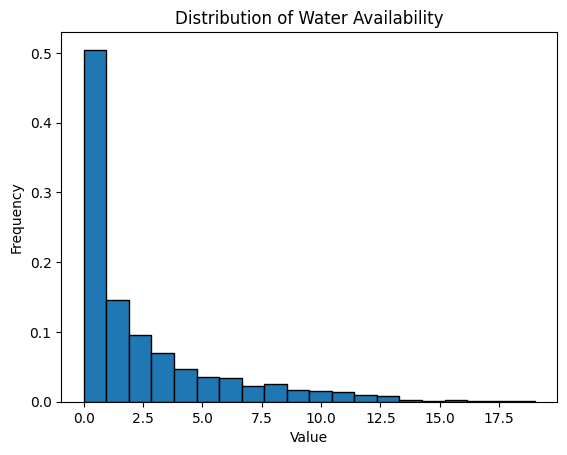

In [12]:

flattened_arr = np.array(ALL_FirstTrlWaterAvai_REC, dtype=float).flatten()

# Filter out NaNs
filtered_arr = flattened_arr[~np.isnan(flattened_arr)]

# Plot the distribution
plt.hist(filtered_arr, edgecolor='black', density=True, bins=20)
plt.title('Distribution of Water Availability')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [13]:
len(filtered_arr)

2690

## Poke distribution between ports

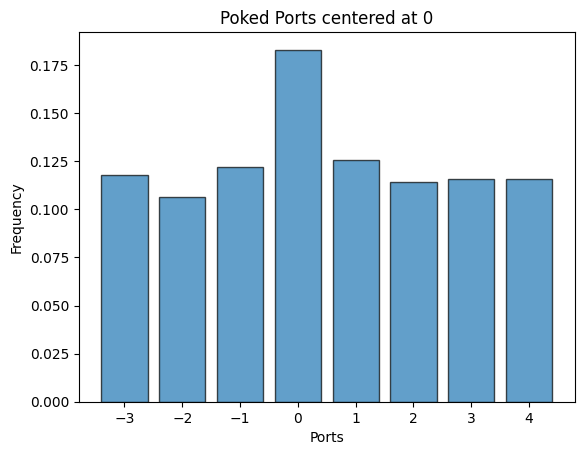

In [14]:
rotated = []
for i in range(len(Big_Hist_data)):
    rotated_hist_seq = np.roll(Big_Hist_data[i], 4 - int(arr_ports[i]))
    rotated.append(rotated_hist_seq)

hist = np.sum(rotated, axis=0)
normalized_hist = hist / np.sum(hist)
bins = np.arange(-3, 5)  # Create bins from -3 to 4

# Plot histogram using bar plot
plt.bar(bins, normalized_hist, edgecolor='black', alpha=0.7)
plt.xlabel('Ports')
plt.ylabel('Frequency')
plt.title('Poked Ports centered at 0') 
plt.xticks(bins)
plt.show()

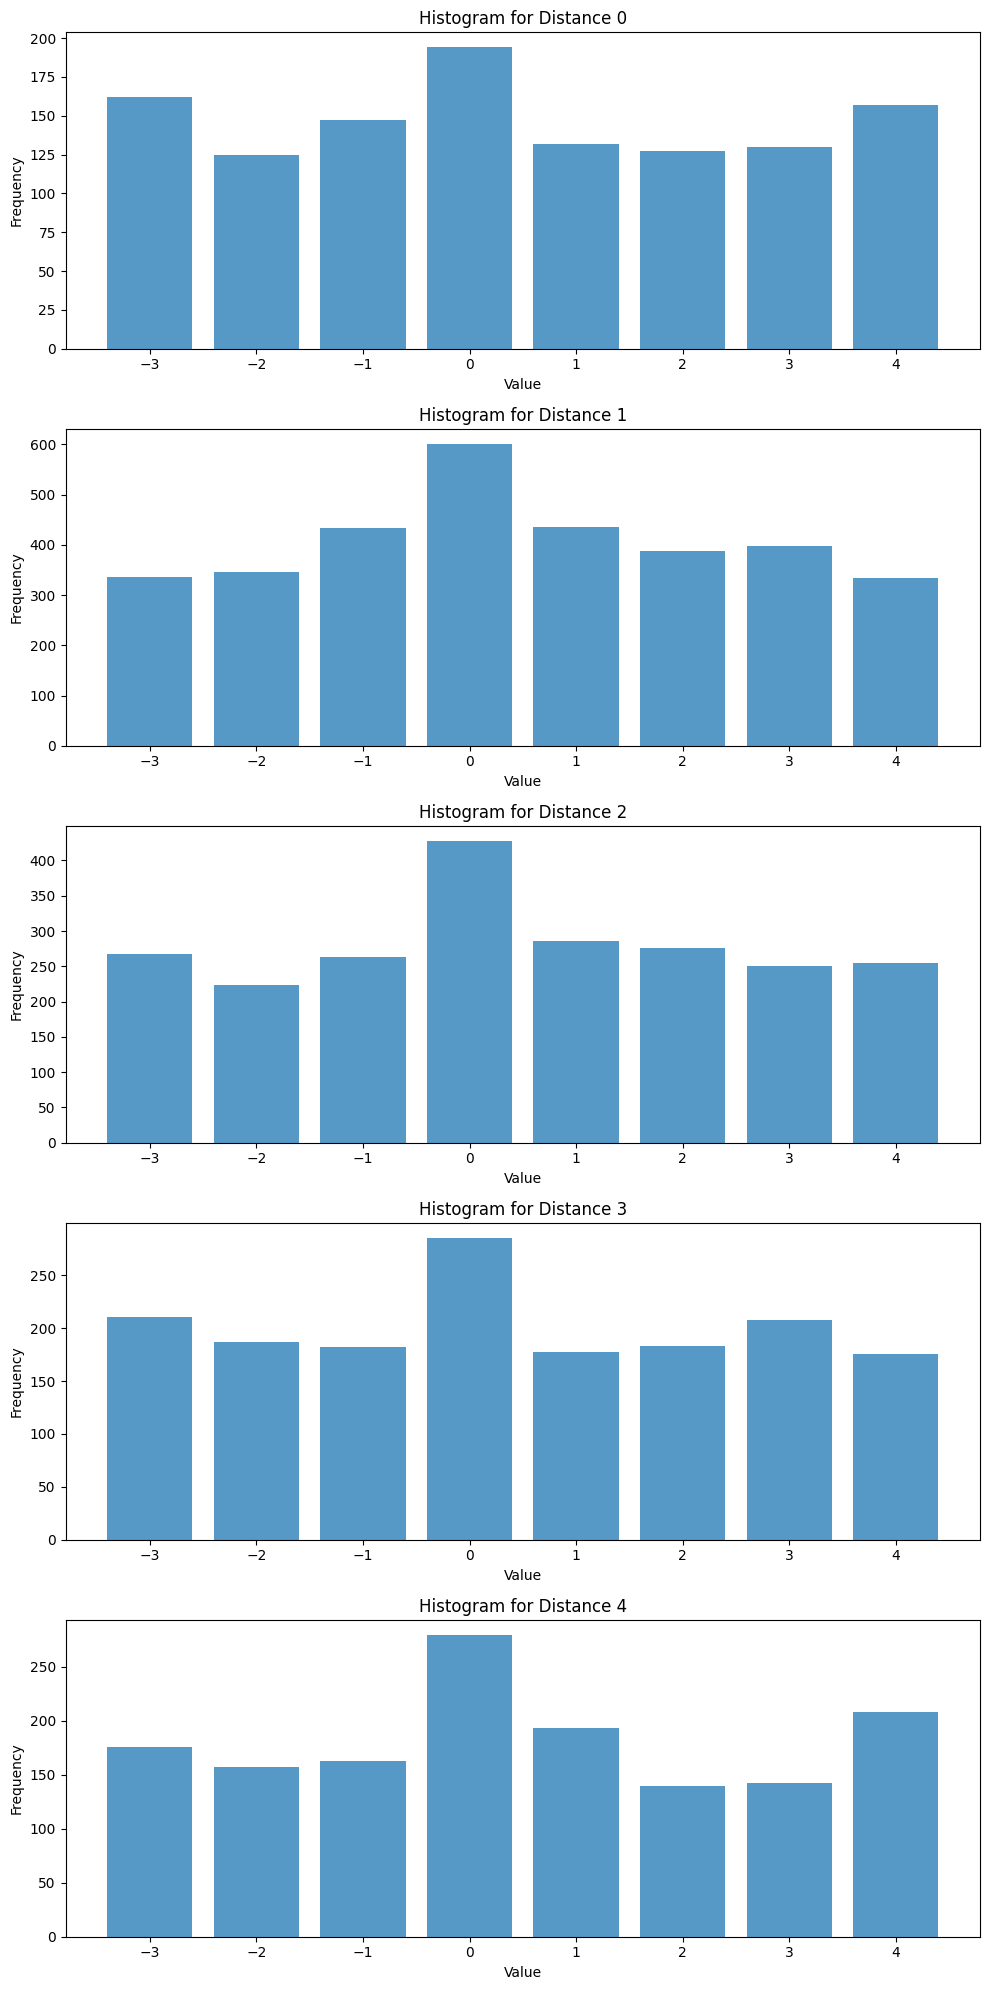

In [15]:
import matplotlib.pyplot as plt

distances = {0: [], 1: [], 2: [], 3: [], 4: []}

for i in range(len(rotated)):
    dist = abs(arr_ports[i] - lags_arr_ports[i]) % 5
    distances[dist].append(rotated[i])

# Plot histograms for each distance category
fig, axs = plt.subplots(5, 1, figsize=(10, 20))
bins = np.arange(-3, 5)
for dist in range(5):
    axs[dist].bar(bins, np.sum(distances[dist], axis=0), alpha=0.75)
    axs[dist].set_title(f'Histogram for Distance {dist}')
    axs[dist].set_xlabel('Value')
    axs[dist].set_ylabel('Frequency')

plt.tight_layout()
plt.show()



## Poke distribution between trials

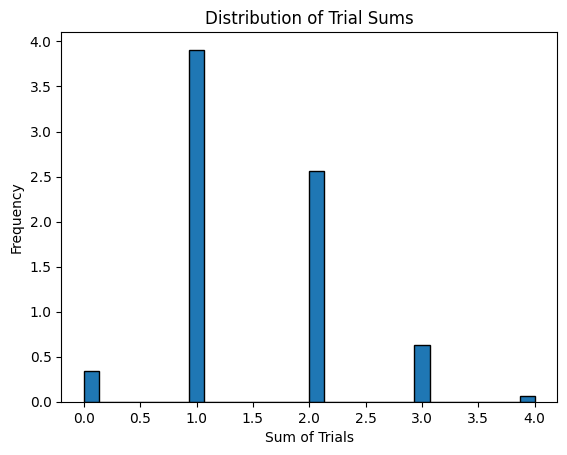

In [16]:
import numpy as np
import matplotlib.pyplot as plt

zero_matrix = np.zeros((1, 8), dtype=int)  # Ensure correct dtype

# Convert sessions to lists before modifying them
filtered_sessions = []
for session in arr_all_trials_pokes:
    session_list = session.tolist()  # Convert NumPy array to a list
    
    # Remove only trailing zero matrices
    while session_list and np.array_equal(np.reshape(session_list[-1], (1, 8)), zero_matrix):
        session_list.pop()  # Remove only from the end
    
    filtered_sessions.append(session_list)  # Append the cleaned session

# Compute trial sums
trial_sums = []
for session in filtered_sessions:
    for trial in session:
        trial_sum = np.sum(trial)
        trial_sums.append(trial_sum)

# Plot the distribution of trial sums
plt.hist(trial_sums, bins=30, edgecolor='black', density=True)
plt.title('Distribution of Trial Sums')
plt.xlabel('Sum of Trials')
plt.ylabel('Frequency')
plt.show()


# LSTM POMDP

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import pickle


# Define POMDP parameters
n_ports = 8  # Number of reward ports
n_trials = 20  # Maximum number of trials before water is available

class DQNLSTM(nn.Module):
    def __init__(self, input_dim, action_dim, hidden_dim=128):
        super(DQNLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.fc1 = nn.Linear(input_dim, 128)
        self.lstm = nn.LSTM(128, hidden_dim, batch_first=True)
        self.fc2 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x, hidden):
        x = torch.relu(self.fc1(x))
        x, hidden = self.lstm(x.unsqueeze(0), hidden)
        x = self.fc2(x.squeeze(0))
        
        #noise = torch.randn_like(x) * 0.05  # Small noise to prevent deterministic behavior
        return x, hidden

    def init_hidden(self):
        return (torch.zeros(1, 1, self.hidden_dim), torch.zeros(1, 1, self.hidden_dim))

class DQNAgent:
    def __init__(self, input_dim, action_dim, gamma=0.99, lr=1e-3, batch_size=16):
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.memory = deque(maxlen=1000)
        
        self.policy_net = DQNLSTM(input_dim, action_dim)
        self.target_net = DQNLSTM(input_dim, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
    
    import torch
    import random


    def select_action_old(self, state, hidden, last_action, trial_first_poke, epsilon=0.2, distance_bias=0.5, repeat_penalty=5.0):
        """
        Select an action with distance bias and penalty for repeating the same port within a trial.

        Args:
            state (torch.Tensor): The current state tensor.
            hidden (tuple): The hidden state of the LSTM.
            last_action (int): Last poked port (only used if NOT the first poke of a trial).
            trial_first_poke (bool): True if this is the first poke of the trial.
            epsilon (float): Exploration probability.
            distance_bias (float): Strength of distance-based preference.
            repeat_penalty (float): Penalty for repeating the same port.

        Returns:
            action (int): Selected action (port to poke next).
            hidden (tuple): Updated LSTM hidden state.
        """
        
        num_ports = self.action_dim  # Assuming 8 ports

        if random.random() < epsilon:
            action = random.randint(0, num_ports - 1)
            return action, hidden

        with torch.no_grad():
            q_values, hidden = self.policy_net(state, hidden)

            if trial_first_poke:
                # No penalties for first poke
                action = torch.argmax(q_values).item()
            else:
                distances = torch.tensor([
                    min(abs(a - last_action), num_ports - abs(a - last_action)) 
                    for a in range(num_ports)
                ], dtype=torch.float32)

                distance_weights = torch.exp(-distance_bias * distances)
                
                weighted_q_values = q_values * distance_weights

                # Apply a penalty to the previously poked port
                penalty_mask = torch.zeros_like(q_values)
                penalty_mask[0, last_action] = -repeat_penalty

                final_q_values = weighted_q_values + penalty_mask
                probs = torch.softmax(final_q_values / 0.5, dim=-1)
                action = torch.multinomial(probs, 1).item()

            return action, hidden
        


    def select_action(self, state, hidden, last_action, trial_first_poke, epsilon=0.2, distance_bias=0.2, repeat_penalty=5.0, neighbor_width=1):
        """
        Select an action with strong bias toward neighboring ports and penalty for repeats.

        Args:
            state (torch.Tensor): The current state tensor.
            hidden (tuple): The hidden state of the LSTM.
            last_action (int): Last poked port.
            trial_first_poke (bool): True if first poke of trial.
            epsilon (float): Exploration probability.
            distance_bias (float): Sharpness of decay with distance.
            repeat_penalty (float): Penalty for repeating same port.
            neighbor_width (int): How many ports away are considered neighbors (e.g. 1 = immediate neighbors).

        Returns:
            action (int): Chosen port.
            hidden (tuple): Updated hidden state.
        """

        num_ports = self.action_dim

        if random.random() < epsilon:
            action = random.randint(0, num_ports - 1)
            return action, hidden

        with torch.no_grad():
            q_values, hidden = self.policy_net(state, hidden)

            if trial_first_poke:
                action = torch.argmax(q_values).item()
            else:
                distances = torch.tensor([
                    min(abs(a - last_action), num_ports - abs(a - last_action))
                    for a in range(num_ports)
                ], dtype=torch.float32)

                # Sharp locality bias
                neighbor_mask = (distances <= neighbor_width).float()

                # Apply both distance exponential and neighbor mask
                distance_weights = torch.exp(-distance_bias * distances) * neighbor_mask

                weighted_q_values = q_values * distance_weights

                penalty_mask = torch.zeros_like(q_values)
                penalty_mask[0, last_action] = -repeat_penalty

                final_q_values = weighted_q_values + penalty_mask
                probs = torch.softmax(final_q_values / 0.5, dim=-1)
                action = torch.multinomial(probs, 1).item()

            return action, hidden





    def store_experience(self, experience):
        self.memory.append(experience)

    def train(self):
        if len(self.memory) < self.batch_size:
            return
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones, hiddens = zip(*batch)
        
        states = torch.cat(states)
        next_states = torch.cat(next_states)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.long)
        dones = torch.tensor(dones, dtype=torch.float32)

        q_values, _ = self.policy_net(states, hiddens[0])
        q_values = q_values.gather(1, actions.unsqueeze(1)).squeeze()

        with torch.no_grad():
            next_q_values, _ = self.target_net(next_states, hiddens[0])
            max_next_q_values = next_q_values.max(1)[0]
            target_q_values = rewards + (1 - dones) * self.gamma * max_next_q_values

        loss = self.loss_fn(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    
    def update_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

def plot_strategy_evolution(strategy_counts):
    """
    Plot the mean evolution of the three strategies over trials.
    Color intervals with the color of the line that has the max value during trials.
    """
    plt.figure(figsize=(10, 6))
    
    # Plot the strategy lines
    plt.plot(range(np.shape(strategy_counts)[0]), strategy_counts[:, 0], label="Exploration", linestyle='dashed', color='green')
    plt.plot(range(np.shape(strategy_counts)[0]), strategy_counts[:, 1], label="Correct Port", linestyle='solid', color='blue')
    plt.plot(range(np.shape(strategy_counts)[0]), strategy_counts[:, 2], label="Yesterday's Correct Port", linestyle='dotted', color='red')
    
    # Fill the intervals with the color of the line that has the max value during trials
    for i in range(np.shape(strategy_counts)[0]):
        max_index = np.argmax(strategy_counts[i])
        if max_index == 0:
            plt.axvspan(i, i+1, facecolor='green', alpha=0.1)
        elif max_index == 1:
            plt.axvspan(i, i+1, facecolor='blue', alpha=0.1)
        elif max_index == 2:
            plt.axvspan(i, i+1, facecolor='red', alpha=0.1)
    
    plt.xlabel("Trials")
    plt.ylabel("Mean Strategy Probability")
    plt.xlim(1, 19)
    plt.title("Strategy Evolution Across Trials")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_histogram(Big_Hist_data, arr_ports):
    rotated = []
    for i in range(len(Big_Hist_data)):
        rotated_hist_seq = np.roll(Big_Hist_data[i], 3 - int(arr_ports[i]))
        rotated.append(rotated_hist_seq)

    hist = np.sum(rotated, axis=0)
    normalized_hist = hist / np.sum(hist)
    bins = np.arange(-3, 5)  # Create bins from -3 to 4

    # Plot histogram using bar plot
    plt.bar(bins, normalized_hist, edgecolor='black', alpha=0.7)
    plt.xlabel('Ports')
    plt.ylabel('Frequency')
    plt.title('Histogram of Frequencies')
    plt.xticks(bins)
    plt.show()

    return normalized_hist

def initialize_belief(kappa=3, w_today=0.3, w_yesterday=0.2, water_availability_dist=filtered_arr):

    thetas = np.linspace(0, 2*np.pi, n_ports+1)[:-1]
    
    r_true_today = np.random.randint(0, n_ports)
    r_true_yesterday = np.random.randint(0, n_ports)

    #print('Correct Port from yesterday: ', r_true_yesterday)
    #print('Correct Port from today: ', r_true_today)
    
    f_r_today = np.exp(kappa * np.cos(thetas - thetas[r_true_today]))
    f_r_today /= f_r_today.sum()  
    
    f_r_yesterday = np.exp(kappa * np.cos(thetas - thetas[r_true_yesterday]))
    f_r_yesterday /= f_r_yesterday.sum()


    f_r_exploration = np.exp(0.015 * np.cos(thetas - thetas[r_true_today]))
    f_r_exploration /= f_r_exploration.sum()  
    
    f_r = w_today * f_r_today + w_yesterday * f_r_yesterday + 0.001 * f_r_exploration
    f_r /= f_r.sum()
    
    #tau_true = np.random.choice(water_availability_dist)
    tau_true = np.random.randint(1, n_trials+1)
    g_tau = np.ones(n_trials) / n_trials
    
    b_prior = np.outer(f_r, g_tau)

    last_visit = np.zeros(n_ports, dtype=int)
    
    return b_prior, r_true_today, tau_true, last_visit, r_true_yesterday



def update_belief(b, w, p, t, last_visit):
    n_ports, n_trials = b.shape
    b_new = np.copy(b)
    
    reward_likelihood = (t >= np.arange(n_trials)) * (p == np.arange(n_ports)[:, None])
    
    if w == 1:
        b_new[:, :] = 0
        b_new[p, :] = reward_likelihood[p, :]
    else:
        update_factor = 1 - reward_likelihood
        b_new *= update_factor
    
    b_new /= np.sum(b_new) if np.sum(b_new) > 0 else 1
    
    marginal_belief = np.sum(b_new, axis=1)
    term_prob = marginal_belief[p] * (t - last_visit[p]) / (n_trials - last_visit[p])
    
    last_visit[p] = t
    
    return b_new, term_prob, last_visit






def simulate(n_episodes=5000, max_pokes=4, epsilon_decay=0.99, epsilon_min=0.1,pokes_per_trial_dist=trial_sums , water_availability_dist=filtered_arr, kappa=3, w_today=0.3, w_yesterday=0.2, epsilon=0.2):
    agent = DQNAgent(input_dim=n_ports * n_trials + n_ports + 1, action_dim=n_ports)
    strategy_counts = np.zeros((n_trials, 3))
    Big_Hist_data = []
    poke_sequences_sim = []
    arr_ports = []
    distances_sim = {0: [], 1: [], 2: [], 3: [], 4: []}
    
    for episode in range(n_episodes):
        b_prior, r_true, tau_true, last_visit, prev_r_true = initialize_belief(kappa=kappa, w_today=w_today, w_yesterday=w_yesterday)
        dist = abs(r_true - prev_r_true) % 5
        poke_distribution = np.zeros(n_ports)
        last_visits = [None] * n_ports
        phase = 0
        done = False
        for t in range(n_trials):
            poke_sequences_sim_trial = []
            max_pokes = np.random.choice(pokes_per_trial_dist)
            trial_first_poke = True  # Reset for each trial
            last_action = None
            for s in range(max_pokes):
                hidden = agent.policy_net.init_hidden()

                state_vector = np.concatenate([
                                b_prior.flatten(),       # flattened belief state (160 elements)
                                last_visit / n_trials,   # normalized last visit array (8 elements)
                                np.array([t / n_trials]) # normalized current trial scalar (1 element)
                            ])
                action, hidden = agent.select_action(torch.tensor(state_vector, dtype=torch.float32).unsqueeze(0), hidden,last_action, trial_first_poke,  epsilon)
                trial_first_poke = False  # Next pokes within trial follow distance bias
                last_action = action  # Update last action for next step
                poke_sequences_sim_trial.append(action+1)
                poke_distribution[action] += 1
                w = int((action == r_true) and (t + 1 >= tau_true))
                b_prior, term_prob, last_visit = update_belief(b_prior, w, action, t, last_visit)
                agent.store_experience((torch.tensor(state_vector, dtype=torch.float32).unsqueeze(0), action, w, torch.tensor(state_vector, dtype=torch.float32).unsqueeze(0), int(t + 1 >= tau_true), hidden))
                agent.train()
                if w:
                    done = True
                    break
            poke_sequences_sim.append(poke_sequences_sim_trial)
            if done:
                break


            
        



        poke_ratios = poke_distribution / poke_distribution.sum()
        correct_port_ratio = poke_ratios[r_true]
        prev_correct_ratio = poke_ratios[prev_r_true] if prev_r_true is not None else 0
        exploration_ratio = (poke_ratios.max() < 0.4)
        
        if exploration_ratio and poke_distribution.sum() > 0:
            strategy_counts[t, 0] += 1  # Exploration
        elif correct_port_ratio == poke_ratios.max():
            strategy_counts[t, 1] += 1  # Correct port
        elif prev_correct_ratio == poke_ratios.max():
            strategy_counts[t, 2] += 1  # Yesterday's correct port
        
        Big_Hist_data.append(poke_distribution)
        distances_sim[dist].append(np.roll(poke_distribution, 3 - r_true))
        arr_ports.append(r_true)
        
        agent.update_target()
        epsilon = max(epsilon * epsilon_decay, epsilon_min)
    strategy_counts /= n_episodes
    plot_strategy_evolution(strategy_counts)
    simulated_hist = plot_histogram(Big_Hist_data, arr_ports)


    return simulated_hist, distances_sim, poke_sequences_sim

#simulated_hist, poke_sequences_sim, poke_distribution = simulate(kappa=3, w_today=0.3, w_yesterday=0.2)

In [ ]:
simulated_hist_RL, distances_sim_RL, poke_sequences_sim_RL = simulate(
                    n_episodes=5000,
                    max_pokes=4,
                    epsilon_decay=0.99,
                    epsilon_min=0.1,
                    pokes_per_trial_dist=trial_sums,
                    water_availability_dist=filtered_arr,
                    kappa=0.5, 
                    w_today=0.3, 
                    w_yesterday=0.2
                )

C:\Users\User\AppData\Local\Temp\ipykernel_29536\938207451.py:294: RuntimeWarning: invalid value encountered in scalar divide
  term_prob = marginal_belief[p] * (t - last_visit[p]) / (n_trials - last_visit[p])


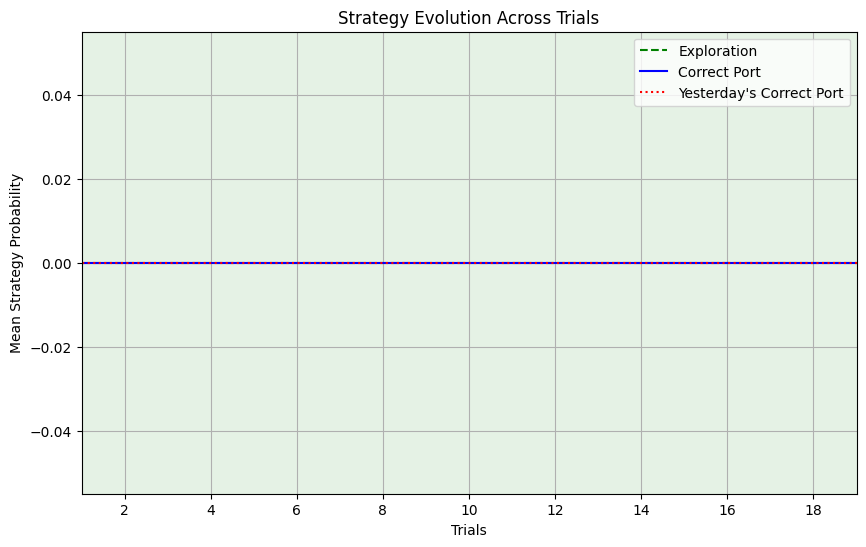

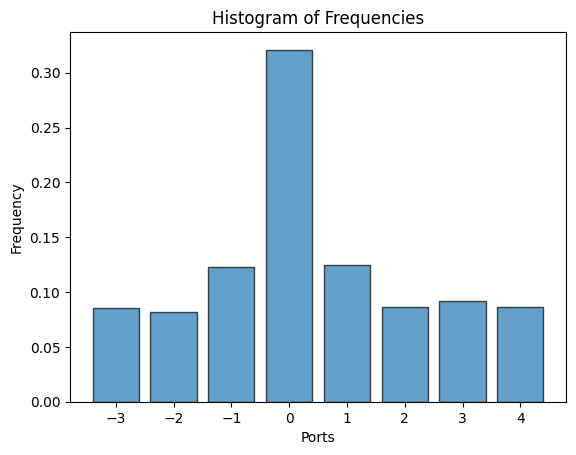

In [26]:
simulated_hist_RL, distances_sim_RL, poke_sequences_sim_RL = simulate(
                    n_episodes=5000,
                    max_pokes=4,
                    epsilon_decay=0.99,
                    epsilon_min=0.1,
                    pokes_per_trial_dist=trial_sums,
                    water_availability_dist=filtered_arr,
                    kappa=3, 
                    w_today=0.3, 
                    w_yesterday=0.2
                )

In [1]:
simulated_hist_RL

NameError: name 'simulated_hist_RL' is not defined

# RL POMDP (Just two beliefs values)

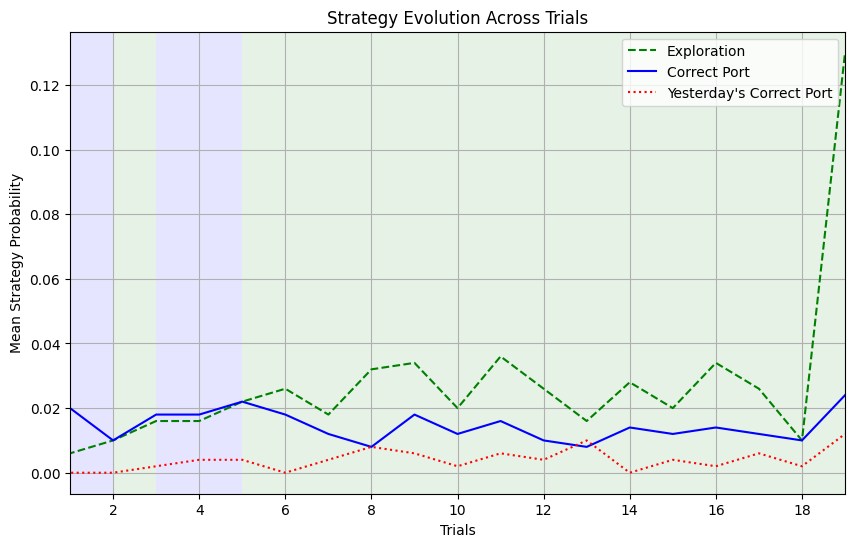

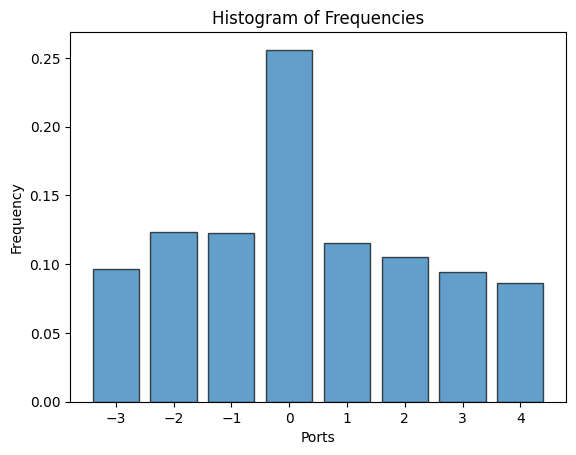

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import pickle


# Define POMDP parameters
n_ports = 8  # Number of reward ports
n_trials = 20  # Maximum number of trials before water is available

class DQNLSTM(nn.Module):
    def __init__(self, input_dim, action_dim, hidden_dim=128):
        super(DQNLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.fc1 = nn.Linear(input_dim, 128)
        self.lstm = nn.LSTM(128, hidden_dim, batch_first=True)
        self.fc2 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x, hidden):
        x = torch.relu(self.fc1(x))
        x, hidden = self.lstm(x.unsqueeze(0), hidden)
        x = self.fc2(x.squeeze(0))
        
        #noise = torch.randn_like(x) * 0.05  # Small noise to prevent deterministic behavior
        return x, hidden

    def init_hidden(self):
        return (torch.zeros(1, 1, self.hidden_dim), torch.zeros(1, 1, self.hidden_dim))

class DQNAgent:
    def __init__(self, input_dim, action_dim, gamma=0.99, lr=1e-3, batch_size=16):
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.memory = deque(maxlen=1000)
        
        self.policy_net = DQNLSTM(input_dim, action_dim)
        self.target_net = DQNLSTM(input_dim, action_dim)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
    
    import torch
    import random


    def select_action_old(self, state, hidden, last_action, trial_first_poke, epsilon=0.2, distance_bias=0.5, repeat_penalty=5.0):
        """
        Select an action with distance bias and penalty for repeating the same port within a trial.

        Args:
            state (torch.Tensor): The current state tensor.
            hidden (tuple): The hidden state of the LSTM.
            last_action (int): Last poked port (only used if NOT the first poke of a trial).
            trial_first_poke (bool): True if this is the first poke of the trial.
            epsilon (float): Exploration probability.
            distance_bias (float): Strength of distance-based preference.
            repeat_penalty (float): Penalty for repeating the same port.

        Returns:
            action (int): Selected action (port to poke next).
            hidden (tuple): Updated LSTM hidden state.
        """
        
        num_ports = self.action_dim  # Assuming 8 ports

        if random.random() < epsilon:
            action = random.randint(0, num_ports - 1)
            return action, hidden

        with torch.no_grad():
            q_values, hidden = self.policy_net(state, hidden)

            if trial_first_poke:
                # No penalties for first poke
                action = torch.argmax(q_values).item()
            else:
                distances = torch.tensor([
                    min(abs(a - last_action), num_ports - abs(a - last_action)) 
                    for a in range(num_ports)
                ], dtype=torch.float32)

                distance_weights = torch.exp(-distance_bias * distances)
                
                weighted_q_values = q_values * distance_weights

                # Apply a penalty to the previously poked port
                penalty_mask = torch.zeros_like(q_values)
                penalty_mask[0, last_action] = -repeat_penalty

                final_q_values = weighted_q_values + penalty_mask
                probs = torch.softmax(final_q_values / 0.5, dim=-1)
                action = torch.multinomial(probs, 1).item()

            return action, hidden
        


    def select_action(self, state, hidden, last_action, trial_first_poke, epsilon=0.2, distance_bias=0.2, repeat_penalty=5.0, neighbor_width=1):
        """
        Select an action with strong bias toward neighboring ports and penalty for repeats.

        Args:
            state (torch.Tensor): The current state tensor.
            hidden (tuple): The hidden state of the LSTM.
            last_action (int): Last poked port.
            trial_first_poke (bool): True if first poke of trial.
            epsilon (float): Exploration probability.
            distance_bias (float): Sharpness of decay with distance.
            repeat_penalty (float): Penalty for repeating same port.
            neighbor_width (int): How many ports away are considered neighbors (e.g. 1 = immediate neighbors).

        Returns:
            action (int): Chosen port.
            hidden (tuple): Updated hidden state.
        """

        num_ports = self.action_dim

        if random.random() < epsilon:
            action = random.randint(0, num_ports - 1)
            return action, hidden

        with torch.no_grad():
            q_values, hidden = self.policy_net(state, hidden)

            if trial_first_poke:
                action = torch.argmax(q_values).item()
            else:
                distances = torch.tensor([
                    min(abs(a - last_action), num_ports - abs(a - last_action))
                    for a in range(num_ports)
                ], dtype=torch.float32)

                # Sharp locality bias
                neighbor_mask = (distances <= neighbor_width).float()

                # Apply both distance exponential and neighbor mask
                distance_weights = torch.exp(-distance_bias * distances) * neighbor_mask

                weighted_q_values = q_values * distance_weights

                penalty_mask = torch.zeros_like(q_values)
                penalty_mask[0, last_action] = -repeat_penalty

                final_q_values = weighted_q_values + penalty_mask
                probs = torch.softmax(final_q_values / 0.5, dim=-1)
                action = torch.multinomial(probs, 1).item()

            return action, hidden





    def store_experience(self, experience):
        self.memory.append(experience)

    def train(self):
        if len(self.memory) < self.batch_size:
            return
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones, hiddens = zip(*batch)
        
        states = torch.cat(states)
        next_states = torch.cat(next_states)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.long)
        dones = torch.tensor(dones, dtype=torch.float32)

        q_values, _ = self.policy_net(states, hiddens[0])
        q_values = q_values.gather(1, actions.unsqueeze(1)).squeeze()

        with torch.no_grad():
            next_q_values, _ = self.target_net(next_states, hiddens[0])
            max_next_q_values = next_q_values.max(1)[0]
            target_q_values = rewards + (1 - dones) * self.gamma * max_next_q_values

        loss = self.loss_fn(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    
    def update_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

def plot_strategy_evolution(strategy_counts):
    """
    Plot the mean evolution of the three strategies over trials.
    Color intervals with the color of the line that has the max value during trials.
    """
    plt.figure(figsize=(10, 6))
    
    # Plot the strategy lines
    plt.plot(range(np.shape(strategy_counts)[0]), strategy_counts[:, 0], label="Exploration", linestyle='dashed', color='green')
    plt.plot(range(np.shape(strategy_counts)[0]), strategy_counts[:, 1], label="Correct Port", linestyle='solid', color='blue')
    plt.plot(range(np.shape(strategy_counts)[0]), strategy_counts[:, 2], label="Yesterday's Correct Port", linestyle='dotted', color='red')
    
    # Fill the intervals with the color of the line that has the max value during trials
    for i in range(np.shape(strategy_counts)[0]):
        max_index = np.argmax(strategy_counts[i])
        if max_index == 0:
            plt.axvspan(i, i+1, facecolor='green', alpha=0.1)
        elif max_index == 1:
            plt.axvspan(i, i+1, facecolor='blue', alpha=0.1)
        elif max_index == 2:
            plt.axvspan(i, i+1, facecolor='red', alpha=0.1)
    
    plt.xlabel("Trials")
    plt.ylabel("Mean Strategy Probability")
    plt.xlim(1, 19)
    plt.title("Strategy Evolution Across Trials")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_histogram(Big_Hist_data, arr_ports):
    rotated = []
    for i in range(len(Big_Hist_data)):
        rotated_hist_seq = np.roll(Big_Hist_data[i], 3 - int(arr_ports[i]))
        rotated.append(rotated_hist_seq)

    hist = np.sum(rotated, axis=0)
    normalized_hist = hist / np.sum(hist)
    bins = np.arange(-3, 5)  # Create bins from -3 to 4

    # Plot histogram using bar plot
    plt.bar(bins, normalized_hist, edgecolor='black', alpha=0.7)
    plt.xlabel('Ports')
    plt.ylabel('Frequency')
    plt.title('Histogram of Frequencies')
    plt.xticks(bins)
    plt.show()

    return normalized_hist




def initialize_belief(kappa=3, w_today=0.3, w_yesterday=0.2, water_availability_dist=filtered_arr):
    thetas = np.linspace(0, 2 * np.pi, n_ports + 1)[:-1]
    
    r_true_today = np.random.randint(0, n_ports)
    r_true_yesterday = np.random.randint(0, n_ports)

    # Initialize belief for today's correct port
    f_r_today = np.zeros(n_ports)
    f_r_today[r_true_today] = 1.0  # Only the correct port of today has a non-zero value

    # Initialize belief for yesterday's correct port
    f_r_yesterday = np.zeros(n_ports)
    f_r_yesterday[r_true_yesterday] = 1.0  # Only the correct port of yesterday has a non-zero value

    # Combine today's and yesterday's beliefs
    f_r = w_today * f_r_today + w_yesterday * f_r_yesterday
    f_r /= f_r.sum()  # Normalize the combined belief

    # Initialize trial distribution
    tau_true = np.random.randint(1, n_trials + 1)
    g_tau = np.ones(n_trials) / n_trials

    # Create the initial belief state
    b_prior = np.outer(f_r, g_tau)

    # Initialize last visit times
    last_visit = np.zeros(n_ports, dtype=int)
    
    return b_prior, r_true_today, tau_true, last_visit, r_true_yesterday



def update_belief(b, w, p, t, last_visit):
    n_ports, n_trials = b.shape
    b_new = np.copy(b)
    
    reward_likelihood = (t >= np.arange(n_trials)) * (p == np.arange(n_ports)[:, None])
    
    if w == 1:
        b_new[:, :] = 0
        b_new[p, :] = reward_likelihood[p, :]
    else:
        update_factor = 1 - reward_likelihood
        b_new *= update_factor
    
    b_new /= np.sum(b_new) if np.sum(b_new) > 0 else 1
    
    marginal_belief = np.sum(b_new, axis=1)
    term_prob = marginal_belief[p] * (t - last_visit[p]) / (n_trials - last_visit[p])
    
    last_visit[p] = t
    
    return b_new, term_prob, last_visit






def simulate(n_episodes=1000, max_pokes=4, epsilon_decay=0.99, epsilon_min=0.1,pokes_per_trial_dist=trial_sums , water_availability_dist=filtered_arr, kappa=3, w_today=0.3, w_yesterday=0.2, epsilon=0.2):
    agent = DQNAgent(input_dim=n_ports * n_trials + n_ports + 1, action_dim=n_ports)
    strategy_counts = np.zeros((n_trials, 3))
    Big_Hist_data = []
    poke_sequences_sim = []
    arr_ports = []
    distances_sim = {0: [], 1: [], 2: [], 3: [], 4: []}
    
    for episode in range(n_episodes):
        b_prior, r_true, tau_true, last_visit, prev_r_true = initialize_belief(kappa=kappa, w_today=w_today, w_yesterday=w_yesterday)
        dist = abs(r_true - prev_r_true) % 5
        poke_distribution = np.zeros(n_ports)
        last_visits = [None] * n_ports
        phase = 0
        done = False
        for t in range(n_trials):
            poke_sequences_sim_trial = []
            max_pokes = np.random.choice(pokes_per_trial_dist)
            trial_first_poke = True  # Reset for each trial
            last_action = None
            for s in range(max_pokes):
                if t == 0 and s == 0:
                    hidden = agent.policy_net.init_hidden()

                state_vector = np.concatenate([
                                b_prior.flatten(),       # flattened belief state (160 elements)
                                last_visit / n_trials,   # normalized last visit array (8 elements)
                                np.array([t / n_trials]) # normalized current trial scalar (1 element)
                            ])
                action, hidden = agent.select_action(torch.tensor(state_vector, dtype=torch.float32).unsqueeze(0), hidden,last_action, trial_first_poke,  epsilon)
                trial_first_poke = False  # Next pokes within trial follow distance bias
                last_action = action  # Update last action for next step
                poke_sequences_sim_trial.append(action+1)
                poke_distribution[action] += 1
                w = int((action == r_true) and (t + 1 >= tau_true))
                b_prior, term_prob, last_visit = update_belief(b_prior, w, action, t, last_visit)
                agent.store_experience((torch.tensor(state_vector, dtype=torch.float32).unsqueeze(0), action, w, torch.tensor(state_vector, dtype=torch.float32).unsqueeze(0), int(t + 1 >= tau_true), hidden))
                agent.train()
                if w:
                    done = True
                    break
            poke_sequences_sim.append(poke_sequences_sim_trial)
            if done:
                break


            
        



        poke_ratios = poke_distribution / poke_distribution.sum()
        correct_port_ratio = poke_ratios[r_true]
        prev_correct_ratio = poke_ratios[prev_r_true] if prev_r_true is not None else 0
        exploration_ratio = (poke_ratios.max() < 0.4)
        
        if exploration_ratio and poke_distribution.sum() > 0:
            strategy_counts[t, 0] += 1  # Exploration
        elif correct_port_ratio == poke_ratios.max():
            strategy_counts[t, 1] += 1  # Correct port
        elif prev_correct_ratio == poke_ratios.max():
            strategy_counts[t, 2] += 1  # Yesterday's correct port
        
        Big_Hist_data.append(poke_distribution)
        distances_sim[dist].append(np.roll(poke_distribution, 3 - r_true))
        arr_ports.append(r_true)
        
        agent.update_target()
        epsilon = max(epsilon * epsilon_decay, epsilon_min)
    strategy_counts /= n_episodes
    plot_strategy_evolution(strategy_counts)
    simulated_hist = plot_histogram(Big_Hist_data, arr_ports)


    return simulated_hist, distances_sim, poke_sequences_sim

simulated_hist_RL2, distances_sim_RL2, poke_sequences_sim_RL2 = simulate(n_episodes = 500, kappa=3, w_today=0.3, w_yesterday=0.2, epsilon = 0.8)
#simulated_hist, poke_sequences_sim = simulate()

# Normal POMDP (Marginal Belief greedy policy)

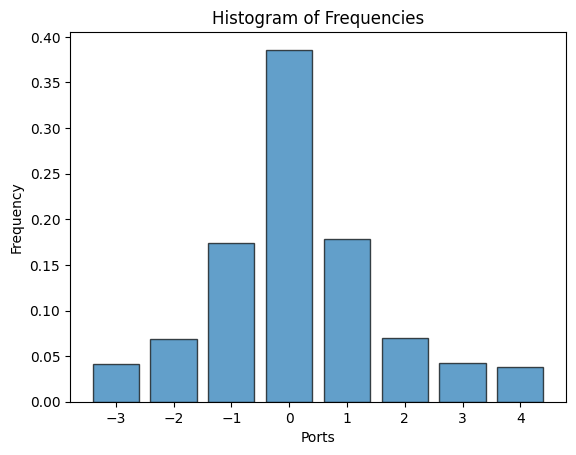

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.animation as animation
from collections import deque

# Define POMDP parameters
n_ports = 8  # Number of reward ports
n_trials = 20  # Maximum number of trials before water is available
arena_radius = 5  # Radius of circular arena


def initialize_belief(kappa=0.5, w_today=0.4, w_yesterday=0.11):

    thetas = np.linspace(0, 2*np.pi, n_ports+1)[:-1]
    
    r_true_today = np.random.randint(0, n_ports)
    r_true_yesterday = np.random.randint(0, n_ports)

    #print('Correct Port from yesterday: ', r_true_yesterday)
    #print('Correct Port from today: ', r_true_today)
    
    f_r_today = np.exp(kappa * np.cos(thetas - thetas[r_true_today]))
    f_r_today /= f_r_today.sum()  
    
    f_r_yesterday = np.exp(kappa * np.cos(thetas - thetas[r_true_yesterday]))
    f_r_yesterday /= f_r_yesterday.sum()


    f_r_exploration = np.exp(0.015 * np.cos(thetas - thetas[r_true_today]))
    f_r_exploration /= f_r_exploration.sum()  
    
    f_r = w_today * f_r_today + w_yesterday * f_r_yesterday + 0.001 * f_r_exploration
    f_r /= f_r.sum()
    
    tau_true = np.random.randint(1, n_trials+1)
    g_tau = np.ones(n_trials) / n_trials
    
    b_prior = np.outer(f_r, g_tau)

    """plt.figure(figsize=(8, 4))
    plt.plot(thetas, f_r, label="Combined Prior")
    plt.plot(thetas, f_r_today, '--', label="Today's Prior", alpha=0.6)
    plt.plot(thetas, f_r_yesterday, '--', label="Yesterday's Prior", alpha=0.6)
    plt.plot(thetas, f_r_exploration, '--', label="Yesterday's Prior", alpha=0.6)
    plt.xlabel("Angle (radians)")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.title("Mixture of Two Von Mises Priors")
    plt.show()"""
    
    
    last_visit = np.zeros(n_ports, dtype=int)
    
    return b_prior, r_true_today, tau_true, last_visit, r_true_yesterday



def update_belief(b, w, p, t, last_visit):
    n_ports, n_trials = b.shape
    b_new = np.copy(b)
    
    reward_likelihood = (t >= np.arange(n_trials)) * (p == np.arange(n_ports)[:, None])
    
    if w == 1:
        b_new[:, :] = 0
        b_new[p, :] = reward_likelihood[p, :]
    else:
        update_factor = 1 - reward_likelihood
        b_new *= update_factor
    
    b_new /= np.sum(b_new) if np.sum(b_new) > 0 else 1
    
    marginal_belief = np.sum(b_new, axis=1)
    term_prob = marginal_belief[p] * (t - last_visit[p]) / (n_trials - last_visit[p])
    
    last_visit[p] = t
    
    return b_new, term_prob, last_visit





def greedy_policy(b):
    marginal_belief = b.sum(axis=1)
    return np.argmax(marginal_belief), marginal_belief








def plot_histogram(Big_Hist_data, arr_ports):
    rotated = []
    for i in range(len(Big_Hist_data)):
        rotated_hist_seq = np.roll(Big_Hist_data[i], 3 - int(arr_ports[i]))
        rotated.append(rotated_hist_seq)

    hist = np.sum(rotated, axis=0)
    normalized_hist = hist / np.sum(hist)
    bins = np.arange(-3, 5)  # Create bins from -3 to 4

    # Plot histogram using bar plot
    plt.bar(bins, normalized_hist, edgecolor='black', alpha=0.7)
    plt.xlabel('Ports')
    plt.ylabel('Frequency')
    plt.title('Histogram of Frequencies')
    plt.xticks(bins)
    plt.show()

    return normalized_hist


import numpy as np
import matplotlib.pyplot as plt
import random

def simulate_multiple_episodes(n_episodes=500,kappa=0.5, w_today=0.3, w_yesterday=0.2):

    strategy_counts = np.zeros((n_trials, 3))  # Track strategy use over trials
    arr_ports = []  # Track the correct ports for each episode
    Big_Hist_data = []  # Track the poke distributions for each episode
    distances_sim = {0: [], 1: [], 2: [], 3: [], 4: []}
    poke_sequences_sim = [] # Track the sequences of pokes for each episode
    
    for episode in range(n_episodes):
        b, r_true, tau_true, last_visit, prev_r_true = initialize_belief(kappa=kappa, w_today=w_today, w_yesterday=w_yesterday)
        dist = abs(r_true - prev_r_true) % 5

        poke_distribution = np.zeros(n_ports)
        done = False
        
        for t in range(n_trials):
            poke_sequences_sim_trial = []
            max_pokes = random.randint(1, 4)
            for _ in range(max_pokes):
                action, _ = greedy_policy(b)
                poke_sequences_sim_trial.append(action+1)
                poke_distribution[action] += 1
                w = int((action == r_true) and (t >= tau_true))
                b, _, _ = update_belief(b, w, action, t, last_visit)
                if w:
                    done = True
                    break
            poke_sequences_sim.append(poke_sequences_sim_trial)
            if done:
                break
        Big_Hist_data.append(poke_distribution)
        arr_ports.append(r_true)
        distances_sim[dist].append(np.roll(poke_distribution, 3 - r_true))

    simulated_hist = plot_histogram(Big_Hist_data, arr_ports)

    
    return simulated_hist, distances_sim, poke_sequences_sim

# Run simulation with different values
n_trials = 20  # Define global n_trials
n_ports = 8  # Define global n_ports
simulated_hist_MB, distances_sim_MB, poke_sequences_sim_MB = simulate_multiple_episodes(n_episodes=5000, kappa=0.5, w_today=0.3, w_yesterday=0.2)



# Normal POMDP (Terminal Probability)

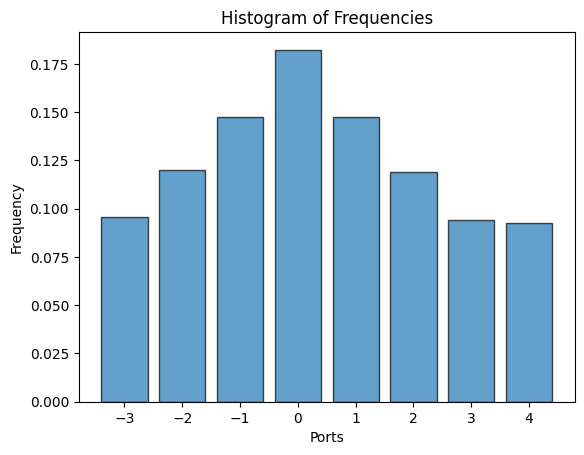

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.animation as animation
from collections import deque

# Define POMDP parameters
n_ports = 8  # Number of reward ports
n_trials = 20  # Maximum number of trials before water is available
arena_radius = 5  # Radius of circular arena


def initialize_belief(kappa=0.5, w_today=0.4, w_yesterday=0.11):

    thetas = np.linspace(0, 2*np.pi, n_ports+1)[:-1]
    
    r_true_today = np.random.randint(0, n_ports)
    r_true_yesterday = np.random.randint(0, n_ports)

    #print('Correct Port from yesterday: ', r_true_yesterday)
    #print('Correct Port from today: ', r_true_today)
    
    f_r_today = np.exp(kappa * np.cos(thetas - thetas[r_true_today]))
    f_r_today /= f_r_today.sum()  
    
    f_r_yesterday = np.exp(kappa * np.cos(thetas - thetas[r_true_yesterday]))
    f_r_yesterday /= f_r_yesterday.sum()


    f_r_exploration = np.exp(0.015 * np.cos(thetas - thetas[r_true_today]))
    f_r_exploration /= f_r_exploration.sum()  
    
    f_r = w_today * f_r_today + w_yesterday * f_r_yesterday + 0.001 * f_r_exploration
    f_r /= f_r.sum()
    
    tau_true = np.random.randint(1, n_trials+1)
    g_tau = np.ones(n_trials) / n_trials
    
    b_prior = np.outer(f_r, g_tau)

    """plt.figure(figsize=(8, 4))
    plt.plot(thetas, f_r, label="Combined Prior")
    plt.plot(thetas, f_r_today, '--', label="Today's Prior", alpha=0.6)
    plt.plot(thetas, f_r_yesterday, '--', label="Yesterday's Prior", alpha=0.6)
    plt.plot(thetas, f_r_exploration, '--', label="Yesterday's Prior", alpha=0.6)
    plt.xlabel("Angle (radians)")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.title("Mixture of Two Von Mises Priors")
    plt.show()"""
    
    
    last_visit = np.zeros(n_ports, dtype=int)
    
    return b_prior, r_true_today, tau_true, last_visit, r_true_yesterday, f_r



def update_belief(b, w, p, t, last_visit):
    n_ports, n_trials = b.shape
    b_new = np.copy(b)
    
    reward_likelihood = (t >= np.arange(n_trials)) * (p == np.arange(n_ports)[:, None])
    
    if w == 1:
        b_new[:, :] = 0
        b_new[p, :] = reward_likelihood[p, :]
    else:
        update_factor = 1 - reward_likelihood
        b_new *= update_factor
    
    b_new /= np.sum(b_new) if np.sum(b_new) > 0 else 1
    
    marginal_belief = np.sum(b_new, axis=1)
    term_prob = marginal_belief[p] * (t - last_visit[p]) / (n_trials - last_visit[p])
    
    last_visit[p] = t
    
    return b_new, term_prob, last_visit





def greedy_policy_eq32(f_theta, last_visit, t):
    scores = f_theta * (t - last_visit)
    return np.argmax(scores), scores









def plot_histogram(Big_Hist_data, arr_ports):
    rotated = []
    for i in range(len(Big_Hist_data)):
        rotated_hist_seq = np.roll(Big_Hist_data[i], 3 - int(arr_ports[i]))
        rotated.append(rotated_hist_seq)

    hist = np.sum(rotated, axis=0)
    normalized_hist = hist / np.sum(hist)
    bins = np.arange(-3, 5)  # Create bins from -3 to 4

    # Plot histogram using bar plot
    plt.bar(bins, normalized_hist, edgecolor='black', alpha=0.7)
    plt.xlabel('Ports')
    plt.ylabel('Frequency')
    plt.title('Histogram of Frequencies')
    plt.xticks(bins)
    plt.show()

    return normalized_hist


import numpy as np
import matplotlib.pyplot as plt
import random

def simulate_multiple_episodes(n_episodes=500, kappa=0.5, w_today=0.3, w_yesterday=0.2):

    strategy_counts = np.zeros((n_trials, 3))  # Track strategy use over trials
    arr_ports = []  # Track the correct ports for each episode
    Big_Hist_data = []  # Track the poke distributions for each episode
    distances_sim = {0: [], 1: [], 2: [], 3: [], 4: []}
    poke_sequences_sim = [] # Track the sequences of pokes for each episode
    
    for episode in range(n_episodes):
        b, r_true, tau_true, last_visit, prev_r_true, f_theta = initialize_belief(kappa, w_today=w_today, w_yesterday=w_yesterday)
        dist = abs(r_true - prev_r_true) % 5
        poke_distribution = np.zeros(n_ports)
        done = False
        
        for t in range(n_trials):
            poke_sequences_sim_trial = []
            max_pokes = random.randint(1, 4)
            for _ in range(max_pokes):
                action, term_prob = greedy_policy_eq32(f_theta, last_visit, t)
                poke_sequences_sim_trial.append(action+1)
                poke_distribution[action] += 1
                w = int((action == r_true) and (t >= tau_true))
                b, term_prob, _ = update_belief(b, w, action, t, last_visit)
                if w:
                    done = True
                    break
            poke_sequences_sim.append(poke_sequences_sim_trial)
            if done:
                break
        Big_Hist_data.append(poke_distribution)
        arr_ports.append(r_true)
        distances_sim[dist].append(np.roll(poke_distribution, 3 - r_true))

    simulated_hist = plot_histogram(Big_Hist_data, arr_ports)

    
    return simulated_hist, distances_sim, poke_sequences_sim

# Run simulation with different values
n_trials = 20  # Define global n_trials
n_ports = 8  # Define global n_ports
simulated_hist_TP, distances_sim_TP, poke_sequences_sim_TP = simulate_multiple_episodes(n_episodes=5000,kappa = 0.5, w_today=0.3, w_yesterday=0.2)


# Results

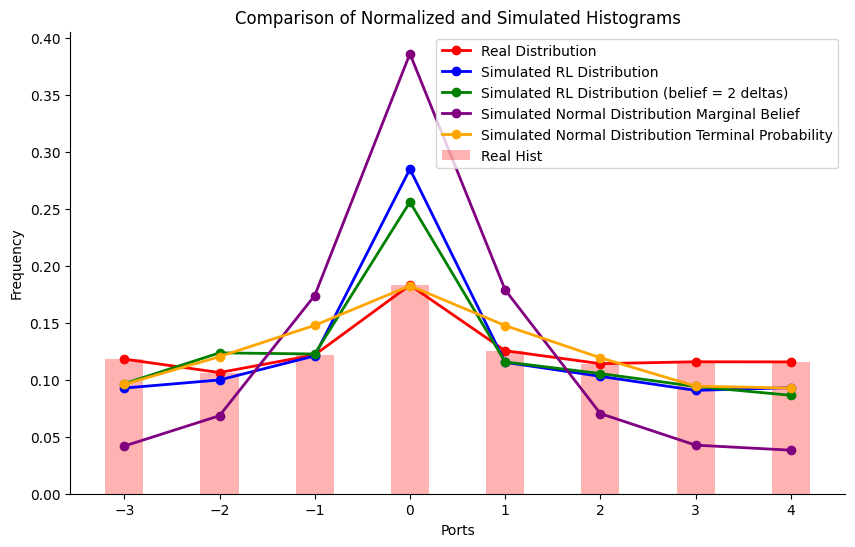

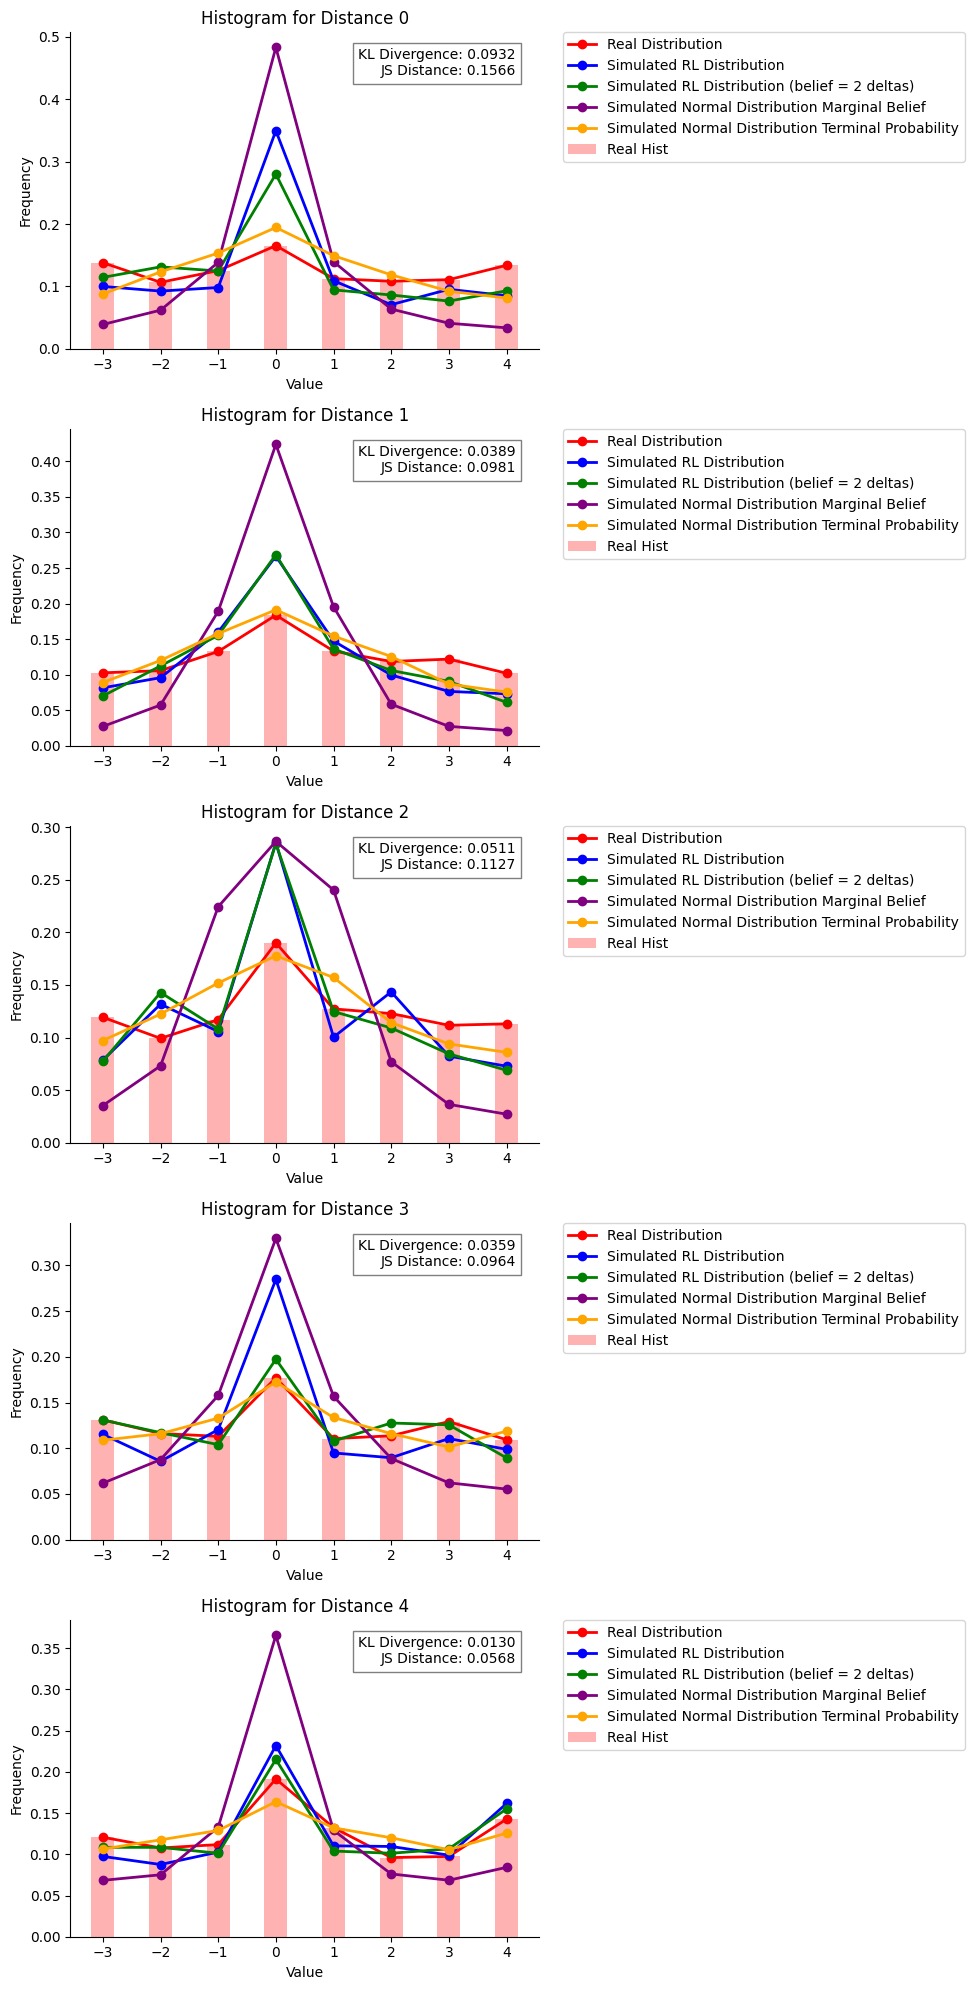

Log-Likelihood of real pokes (under real model): -0.569
Log-Likelihood of simulated pokes (under real model): -1.128


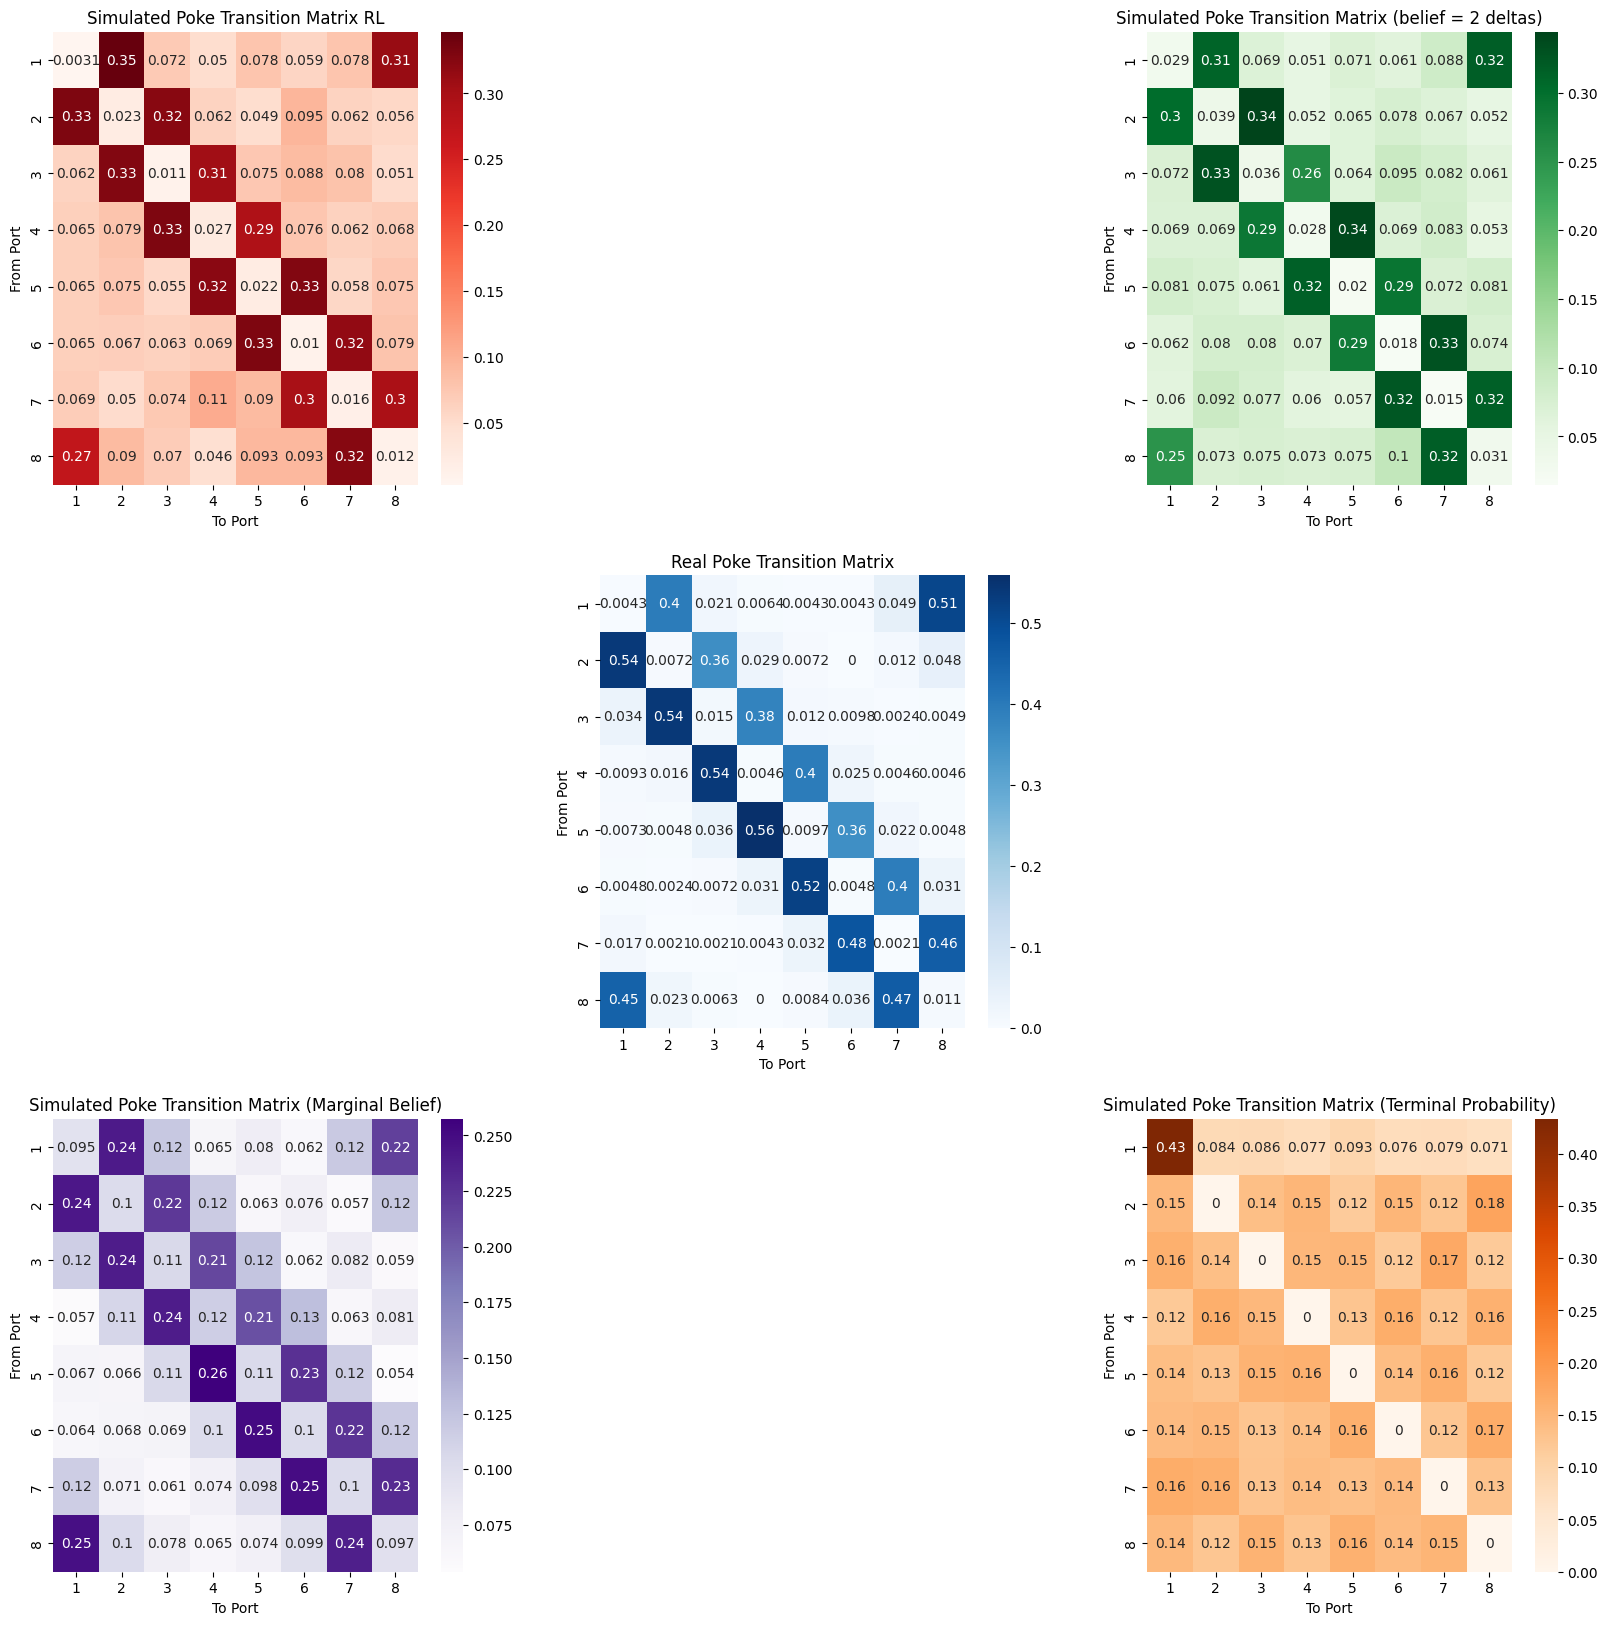

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon



# Plotting the histograms
bins =  np.arange(-3, 5)

plt.figure(figsize=(10, 6))
plt.plot(bins , normalized_hist, marker='o', color='red', label='Real Distribution', linewidth=2)
plt.plot(bins , simulated_hist_RL, marker='o', color='blue', label='Simulated RL Distribution', linewidth=2)
plt.plot(bins , simulated_hist_RL2, marker='o', color='green', label='Simulated RL Distribution (belief = 2 deltas)', linewidth=2)
plt.plot(bins , simulated_hist_MB, marker='o', color='purple', label='Simulated Normal Distribution Marginal Belief', linewidth=2)
plt.plot(bins , simulated_hist_TP, marker='o', color='orange', label='Simulated Normal Distribution Terminal Probability', linewidth=2)
plt.bar(bins, normalized_hist, width=0.4, label='Real Hist', align='center', color='red', alpha=0.3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


plt.xlabel('Ports')
plt.ylabel('Frequency')
plt.title('Comparison of Normalized and Simulated Histograms')
plt.legend()
plt.show()



distances = {0: [], 1: [], 2: [], 3: [], 4: []}

for i in range(len(rotated)):
    dist = abs(arr_ports[i] - lags_arr_ports[i]) % 5
    distances[dist].append(rotated[i])

# Plot histograms for each distance category
fig, axs = plt.subplots(5, 1, figsize=(10, 20))
bins = np.arange(-3, 5)

for dist in range(5):
    hist_values = np.sum(distances[dist], axis=0) / np.sum(distances[dist])
    hist_sim_values = np.sum(distances_sim_RL[dist], axis=0) / np.sum(distances_sim_RL[dist])
    hist_sim_values_2 = np.sum(distances_sim_RL2[dist], axis=0) / np.sum(distances_sim_RL2[dist])
    hist_sim_values_MB = np.sum(distances_sim_MB[dist], axis=0) / np.sum(distances_sim_MB[dist])
    hist_sim_values_TP = np.sum(distances_sim_TP[dist], axis=0) / np.sum(distances_sim_TP[dist])
    
    # Calculate KL divergence and JS distance
    kl_divergence = entropy(hist_values + 1e-10, hist_sim_values + 1e-10)
    js_distance = jensenshannon(hist_values + 1e-10, hist_sim_values + 1e-10)
    
    #axs[dist].bar(bins - 0.2, hist_values, alpha=0.75, width=0.4, label='Normalized Hist', align='center')
    axs[dist].plot(bins , hist_values, marker='o', color='red', label='Real Distribution', linewidth=2)
    axs[dist].plot(bins , hist_sim_values, marker='o', color='blue', label='Simulated RL Distribution', linewidth=2)
    axs[dist].plot(bins , hist_sim_values_2, marker='o', color='green', label='Simulated RL Distribution (belief = 2 deltas)', linewidth=2)
    axs[dist].plot(bins , hist_sim_values_MB, marker='o', color='purple', label='Simulated Normal Distribution Marginal Belief', linewidth=2)
    axs[dist].plot(bins , hist_sim_values_TP, marker='o', color='orange', label='Simulated Normal Distribution Terminal Probability', linewidth=2)
    axs[dist].bar(bins , hist_values,  width=0.4, label='Real Hist', color= 'red',alpha= 0.3, align='center')
    axs[dist].set_title(f'Histogram for Distance {dist}')
    axs[dist].set_xlabel('Value')
    axs[dist].set_ylabel('Frequency')
    # Add the legend outside the graph
    axs[dist].legend(
    loc='upper left',  # Position the legend in the upper left corner
    bbox_to_anchor=(1.05, 1),  # Move the legend outside the axes
    borderaxespad=0,  # Padding between the axes and the legend
    frameon=True  # Add a frame around the legend
    )
    
    # Add text annotations for KL divergence and JS distance
    textstr = f'KL Divergence: {kl_divergence:.4f}\nJS Distance: {js_distance:.4f}'
    axs[dist].text(0.95, 0.95, textstr, transform=axs[dist].transAxes, fontsize=10,
                   verticalalignment='top', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5))
    
    axs[dist].spines['top'].set_visible(False)
    axs[dist].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()





import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
from sklearn.decomposition import PCA

real_pokes = poke_sequences
sim_pokes = poke_sequences_sim_RL
sim_pokes_2 = poke_sequences_sim_RL2
sim_pokes_MB = poke_sequences_sim_MB
sim_pokes_TP = poke_sequences_sim_TP

num_ports = 8  # Total number of ports

# Compute transition probabilities
def compute_transition_matrix(poke_sequences, num_ports=8):
    transition_matrix = np.zeros((num_ports, num_ports))
    counts = np.zeros(num_ports)

    for seq in poke_sequences:
        for i in range(len(seq) - 1):
            from_poke, to_poke = seq[i] - 1, seq[i + 1] - 1
            transition_matrix[from_poke, to_poke] += 1
            counts[from_poke] += 1

    with np.errstate(divide='ignore', invalid='ignore'):
        transition_matrix = np.nan_to_num(transition_matrix / counts[:, None])  # Normalize

    return transition_matrix

# Compute log-likelihood of a sequence given a transition matrix
def compute_log_likelihood(poke_sequences, transition_matrix):
    log_likelihoods = []
    
    for seq in poke_sequences:
        log_prob = 0
        for i in range(len(seq) - 1):
            from_poke, to_poke = seq[i] - 1, seq[i + 1] - 1
            prob = transition_matrix[from_poke, to_poke]
            log_prob += np.log(prob + 1e-6)  # Avoid log(0)
        
        log_likelihoods.append(log_prob)
    
    return np.mean(log_likelihoods)  # Average across trials

# Compute transition matrices
real_transitions = compute_transition_matrix(real_pokes, num_ports)
sim_transitions = compute_transition_matrix(sim_pokes, num_ports)
sim_transitions_2 = compute_transition_matrix(sim_pokes_2, num_ports)
sim_transitions_MB = compute_transition_matrix(sim_pokes_MB, num_ports)
sim_transitions_TP = compute_transition_matrix(sim_pokes_TP, num_ports)


# Compute log-likelihoods
real_log_likelihood = compute_log_likelihood(real_pokes, real_transitions)
sim_log_likelihood = compute_log_likelihood(sim_pokes, real_transitions)
sim_log_likelihood_2 = compute_log_likelihood(sim_pokes_2, real_transitions)
sim_log_likelihood_MB = compute_log_likelihood(sim_pokes_MB, real_transitions)
sim_log_likelihood_TP = compute_log_likelihood(sim_pokes_TP, real_transitions)


# Print log-likelihood results
print(f"Log-Likelihood of real pokes (under real model): {real_log_likelihood:.3f}")
print(f"Log-Likelihood of simulated pokes (under real model): {sim_log_likelihood:.3f}")

# Heatmaps for transition probabilities
plt.figure(figsize=(20, 20))

plt.subplot(3, 3, 5)
sns.heatmap(real_transitions, annot=True, cmap="Blues", xticklabels=range(1, 9), yticklabels=range(1, 9))
plt.title("Real Poke Transition Matrix")
plt.xlabel("To Port")
plt.ylabel("From Port")

plt.subplot(3, 3, 1)
sns.heatmap(sim_transitions, annot=True, cmap="Reds", xticklabels=range(1, 9), yticklabels=range(1, 9))
plt.title("Simulated Poke Transition Matrix RL")
plt.xlabel("To Port")
plt.ylabel("From Port")

plt.subplot(3, 3, 3)
sns.heatmap(sim_transitions_2, annot=True, cmap="Greens", xticklabels=range(1, 9), yticklabels=range(1, 9))
plt.title("Simulated Poke Transition Matrix (belief = 2 deltas)")
plt.xlabel("To Port")
plt.ylabel("From Port")

plt.subplot(3, 3, 7)
sns.heatmap(sim_transitions_MB, annot=True, cmap="Purples", xticklabels=range(1, 9), yticklabels=range(1, 9))
plt.title("Simulated Poke Transition Matrix (Marginal Belief)")
plt.xlabel("To Port")
plt.ylabel("From Port")

plt.subplot(3, 3, 9)
sns.heatmap(sim_transitions_TP, annot=True, cmap="Oranges", xticklabels=range(1, 9), yticklabels=range(1, 9))
plt.title("Simulated Poke Transition Matrix (Terminal Probability)")
plt.xlabel("To Port")
plt.ylabel("From Port")


plt.show()
